In [15]:
# Define problem
# Always two features
# Ideal weight of first feature is always 0.5, ideal weight of second feature is configurable
# Whether features are independent is configurable, when colinear, they are the same target feature with different amounts of noise
# Noise for the first feature is always 0.1, noise for the second feature is configurable
# Note that all of the three lines are like a small version of the feature sifting setup I'm already using with how features are generated with noise coefficients and such


# First experiment:
# Independent features, ideal weight of second feature with ideal weights of 0.1, 0.3, 0.5, 0.7, and 0.9
# The second feature should also have noise of 0.1
# Both features are trained with LMS with a step-size of 0.01 for 100k steps
# I want to plot several plots, vertically stacked, each for a different ideal weight of the second feature
# Each plot should include lines for:
#   - The current weights of both features
#   - A dashed line for the ideal weight of the second feature
#   - Traces of changes to the weights with varying decay rates (0.9, 0.99, 0.999)
#   - h value from IDBD (compute even though learning happens with a constant step-size)
#   - h value from IDBD3 (compute even though learning happens with a constant step-size)


# The goal of this experiment is to figure out which, if any, of the metrics I've mentioned would be sufficient to determine when a feature should be protected
# The indicators I'm considering are traces of changes to the weights, traces to changes to the step-size (when using idbd),
#   and the h value of IDBD or IDBD3 (when its sign flips) (which can be computed even when not using IDBD).


In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def make_problem_data(
    n_steps,
    target_weights,          # teacher weight on each feature's CLEAN signal (scalar or list)
    *,
    feature_noise=0.0,       # noise coefficient c per feature (scalar or list)
    target_noise_std=0.1,    # std of additive Gaussian noise on the target
    shared_signal=False,     # if True, all features are noisy views of ONE signal
    seed=0,
):
    """Generate (features, target) for the feature-sifting linear-regression probe.

    The target is a fixed "teacher network": ``y = sum_j target_weights[j] * s_j
    + noise``, built from the CLEAN signals ``s_j``. The learner instead sees the
    noisy features ``f_j = (1 - c_j) * s_j + c_j * U(-1, 1)``. The teacher weights
    are held fixed regardless of the feature noise; the learner's *optimal* weight
    on a noisy feature is attenuated away from the teacher weight (regression
    dilution -- see ``optimal_weight``), so the dashed reference in the plots is
    the computed optimum, not the teacher weight.

    Every knob that may vary across experiments is a parameter:

    - ``target_weights``: teacher weight per feature on its clean signal -> sets
      the number of features. With clean features (``c = 0``) this is also the
      learner's optimal weight.
    - ``feature_noise``: per-feature noise coefficient ``c`` in
      ``f = (1 - c) * s + c * U(-1, 1)``;  ``c = 0`` gives a clean feature.
    - ``target_noise_std``: std of the Gaussian noise added to the target.
    - ``shared_signal``: if True every feature is a noisy view of the *same*
      underlying signal (the colinear / "blocking" case); otherwise each feature
      has its own independent signal.

    Returns ``features`` (n_steps, n_feat) and ``y`` (n_steps,).
    """
    rng = np.random.default_rng(seed)
    target_weights = np.atleast_1d(np.asarray(target_weights, dtype=float))
    n_feat = len(target_weights)
    c = np.broadcast_to(np.asarray(feature_noise, dtype=float), (n_feat,))

    # underlying clean signals
    if shared_signal:
        s = rng.uniform(-1.0, 1.0, size=n_steps)
        signals = [s] * n_feat
    else:
        signals = [rng.uniform(-1.0, 1.0, size=n_steps) for _ in range(n_feat)]

    features = np.empty((n_steps, n_feat))
    y = rng.normal(0.0, target_noise_std, size=n_steps)
    for j in range(n_feat):
        feat_noise = rng.uniform(-1.0, 1.0, size=n_steps)
        features[:, j] = (1 - c[j]) * signals[j] + c[j] * feat_noise
        y = y + target_weights[j] * signals[j]   # teacher weight on the clean signal

    return features, y


def optimal_weight(target_weight, feature_noise):
    """Least-squares optimal weight on a single *independent* noisy feature.

    With ``f = (1 - c) * s + c * u`` (Var(s) == Var(u)) and target component
    ``target_weight * s``, the optimum is
        ``w* = Cov(f, y) / Var(f) = target_weight * (1 - c) / ((1 - c)**2 + c**2)``.
    The learner shrinks the weight (regression attenuation) as the feature gets
    noisier:  ``w* -> target_weight`` at ``c = 0`` and ``w* -> 0`` as ``c -> 1``.
    Assumes the feature's signal is independent of the other features' signals.
    """
    c = np.asarray(feature_noise, dtype=float)
    return target_weight * (1 - c) / ((1 - c) ** 2 + c ** 2)


In [18]:
# ---------------------------------------------------------------------------
# First experiment: a single feature with clean inputs (no feature noise) and a
# noisy target, learned from a zero weight with constant-step-size LMS, while we
# *observe* candidate "maturity" indicators for its weight.
#
# Learning is plain LMS; the IDBD / IDBD3 h-traces are computed alongside with
# the same constant step-size, exactly as the project optimisers do:
#   IDBD : h <- h * max(1 - step_size*f**2, 0) + step_size * loss_grad
#   IDBD3: h <- h * max(1 - step_size*f**2, 0) +             loss_grad
# with loss_grad = 2*error*f. They never feed back into the weights.
# (With a constant step-size the two share the same decay term and differ only by
#  the factor step_size, so h_idbd == step_size * h_idbd3 exactly -- they coincide
#  once normalized.)
# ---------------------------------------------------------------------------

STEP_SIZE = 0.01
N_STEPS = 10_000
IDEAL_WEIGHTS = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]
TRACE_DECAYS = [0.9, 0.99, 0.999]


def run_lms_with_indicators(features, y, step_size=STEP_SIZE, trace_decays=TRACE_DECAYS,
                            w_init=None):
    """LMS over `features` (n_steps, n_feat); indicators are tracked for the
    feature under study, taken to be the LAST column. `step_size` is the constant
    LMS / IDBD step-size and the number of steps is set by len(features), so both
    are configurable per run. `w_init` defaults to zeros (a fresh weight); pass a
    vector to start e.g. an established weight at its optimum in the later blocking
    experiments."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    h_idbd = 0.0
    h_idbd3 = 0.0
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd_hist = np.empty(n_steps)
    h_idbd3_hist = np.empty(n_steps)

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)

        fi = f[tracked]
        loss_grad = 2.0 * error * fi             # d(error**2)/dw_tracked
        decay_term = fi * fi                     # prediction-grad squared

        # IDBD / IDBD3 h-traces (observed only, constant step-size)
        keep = max(0.0, 1.0 - step_size * decay_term)
        h_idbd = h_idbd * keep + step_size * loss_grad
        h_idbd3 = h_idbd3 * keep + loss_grad

        # LMS weight update (constant step-size) for every weight
        dw = -step_size * (2.0 * error * f)
        w = w + dw

        # EMA traces of the tracked weight's changes with bias correction
        ema_coeff = decays
        corr = 1.0 - ema_coeff ** (t + 1)
        dw_tr = ema_coeff * dw_tr + (1.0 - ema_coeff) * dw[tracked]
        dw_tr_bc = dw_tr / corr  # bias-corrected

        w_hist[t] = w

        dw_trace_hist[t] = dw_tr #dw_tr_bc
        h_idbd_hist[t] = h_idbd
        h_idbd3_hist[t] = h_idbd3

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'h_idbd': h_idbd_hist, 'h_idbd3': h_idbd3_hist}


results = {}
for w_ideal in IDEAL_WEIGHTS:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(N_STEPS, [w_ideal], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results[w_ideal] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


In [19]:
def _norm_peak(a):
    m = np.max(np.abs(a))
    return a / m if m > 0 else a

W_COLOR = 'black'
DW_COLORS = ['#3953e2', '#9923DC', '#029999']  # Brighter indigo, purple, dark aqua
H_IDBD3_COLOR = '#FF3300'  # slightly redder blood orange (stand-out)

### Reading the plots

One panel per ideal weight $w^*$ (including $w^* = 0$ — a useless feature whose weight
should stay at zero). A single feature with clean inputs is learned from a zero weight;
all the noise lives in the target ($\sigma = 0.1$).

**Left axis (true scale, black):** the weight (solid) and its ideal value (dashed). The
grey vertical line marks where the weight first reaches 90% of its ideal — a rough
"matured" reference (omitted for $w^* = 0$).

**Right axis (linear, coloured):** the candidate maturity indicators, each normalized to
unit peak so they are comparable (raw magnitudes differ by orders of magnitude). All are
shown in the weight-change sign convention ($-h$), so each indicator is positive while
the weight grows and collapses toward (and flips around) zero once the weight matures.

The IDBD / IDBD3 $h$-traces use the project's exact recursion
$h_t = h_{t-1}\,\max(1 - \alpha f^2,\,0) + (\alpha\ \text{or}\ 1)\cdot\text{loss\_grad}$,
with $\alpha$ held constant. They share the *same* decay multiplier and their additive
terms differ only by the constant factor $\alpha$, so $h^{\text{IDBD}}_t = \alpha\,
h^{\text{IDBD3}}_t$ for all $t$ — i.e. they are exactly proportional and coincide after
normalization. They only diverge once $\alpha$ is allowed to adapt (then the decay
multipliers differ too), which is a later experiment.


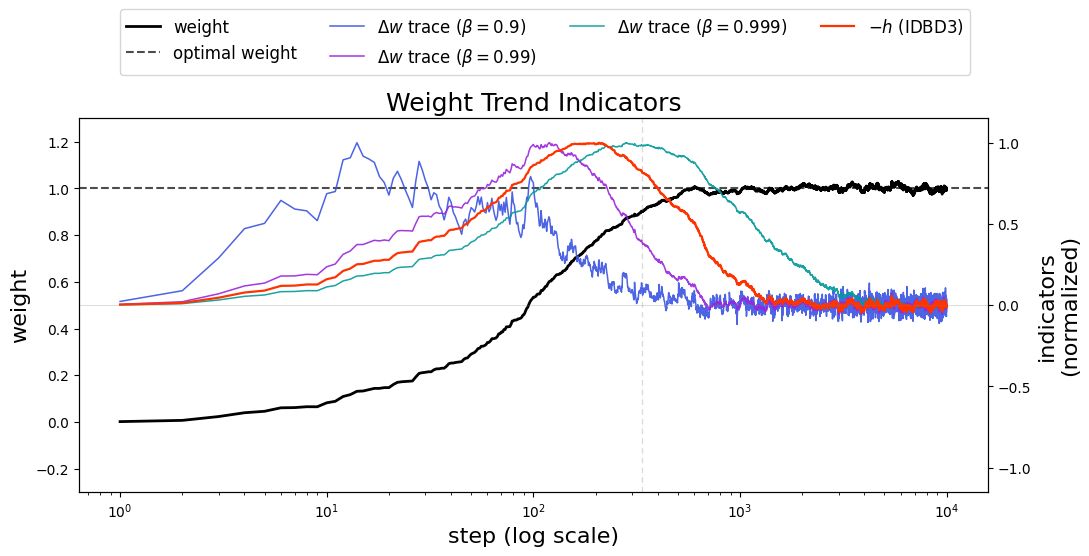

In [20]:

# Only plot the first optimal weight (single plot)
plot_steps = np.arange(1, N_STEPS + 1)

w_ideal = IDEAL_WEIGHTS[-1]
res = results[w_ideal]
w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

fig, ax = plt.subplots(figsize=(11, 5))
# --- left axis: the weight (true scale, black) ---
ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
ax.set_xscale('log')
ax.set_ylabel('weight', fontsize=16)
ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
ax.set_title(f'Weight Trend Indicators', fontsize=18)

# rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
if w_opt > 0:
    hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
    if len(hit):
        ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

# --- right axis: normalized maturity indicators (one colour each) ---
ax2 = ax.twinx()
for k, d in enumerate(TRACE_DECAYS):
    ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
             color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'$\Delta w$ trace ($\\beta = {d}$)')
ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
         label='$-h$ (IDBD3)')
ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
ax2.set_ylim(-1.15, 1.15)
ax2.set_ylabel('indicators\n(normalized)', fontsize=16)

ax.set_xlabel('step (log scale)', fontsize=16)

# Build legend with left and right handles/labels
hL, lL = ax.get_legend_handles_labels()
hR, lR = ax2.get_legend_handles_labels()
# Place the legend just above the axes, closer to the plot to reduce empty space
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.12),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))  # adjust so legend fits closely above plot
plt.show()


/tmp/ipykernel_86173/828059091.py:15: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)


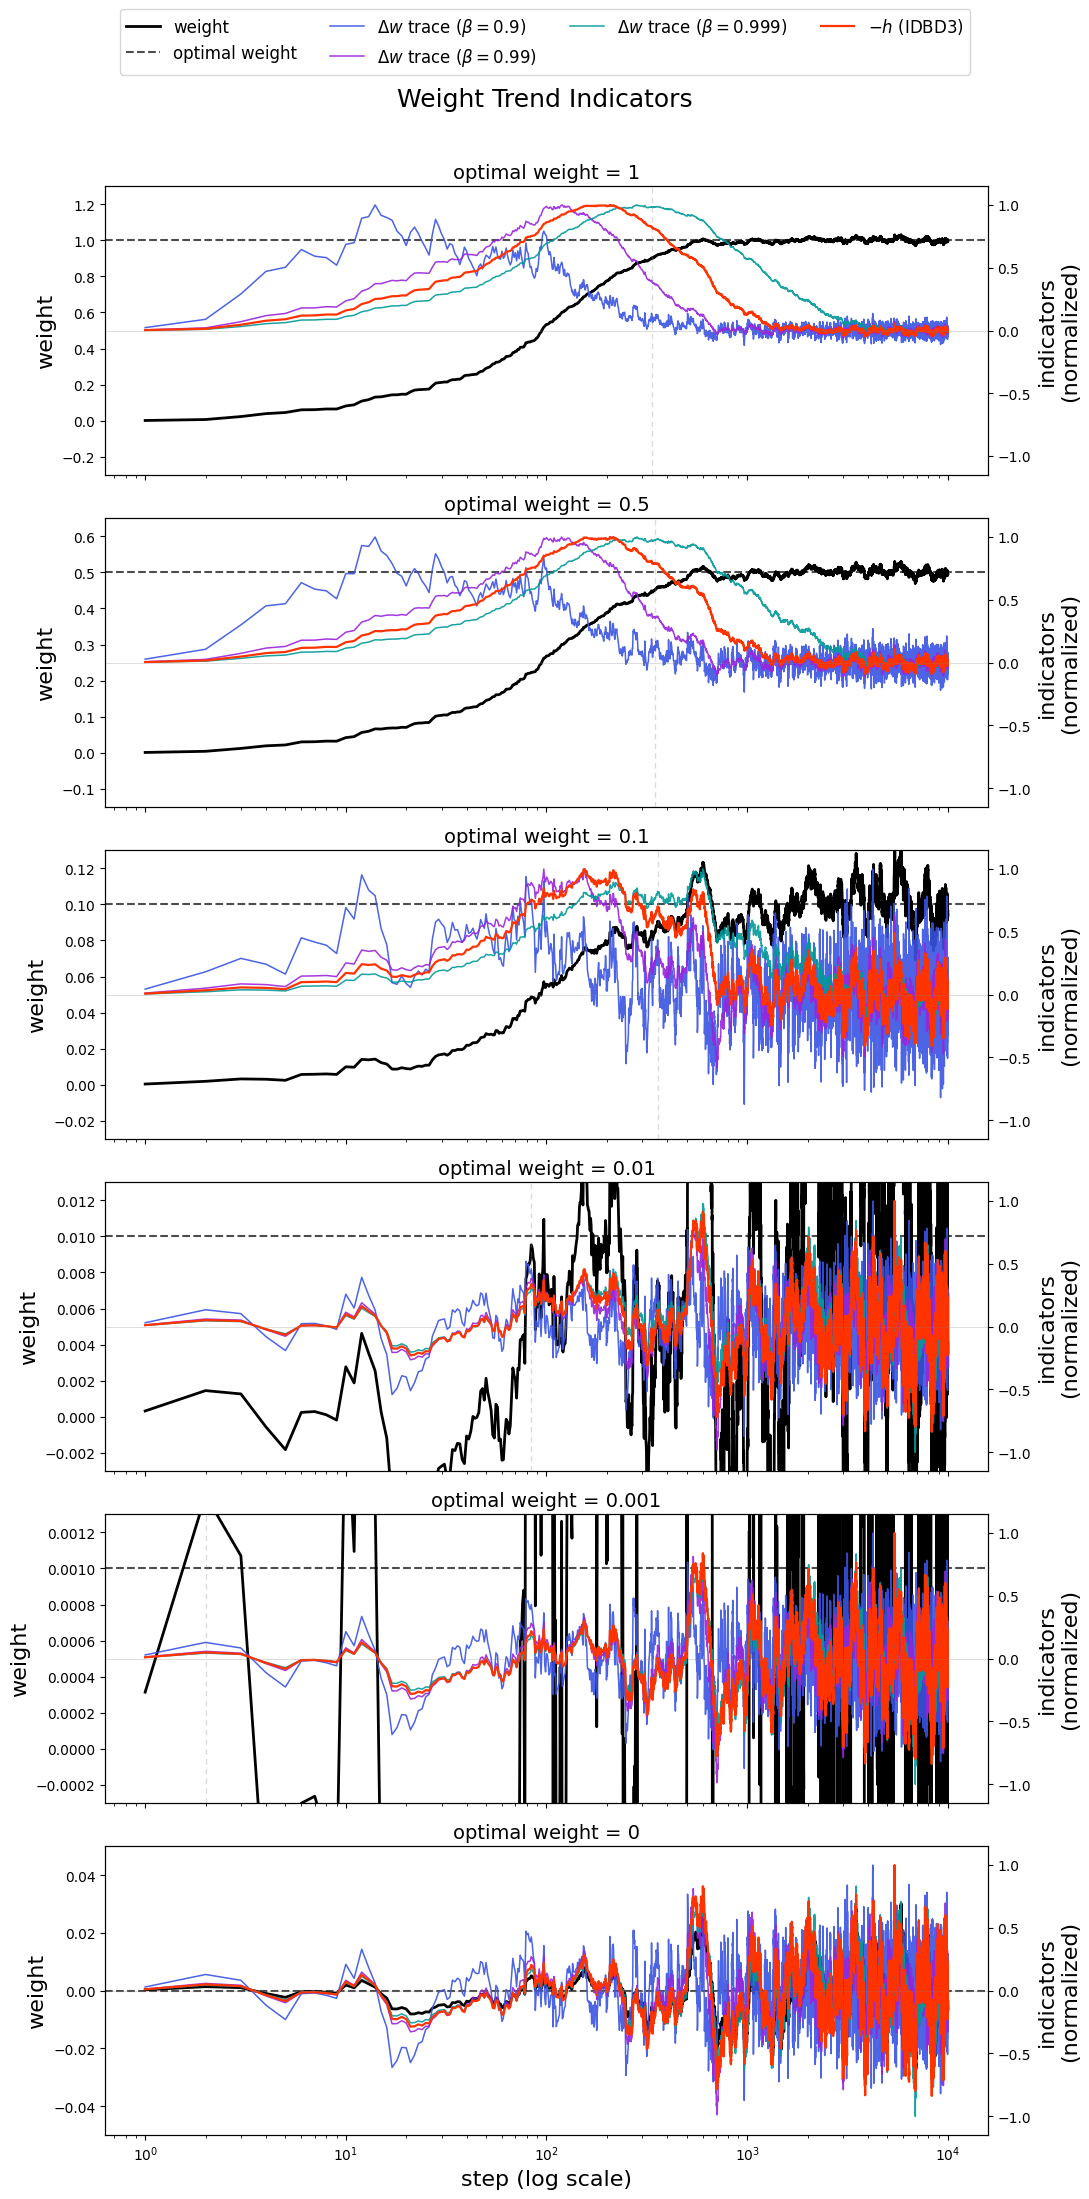

In [21]:
plot_steps = np.arange(1, N_STEPS + 1)
fig, axes = plt.subplots(len(IDEAL_WEIGHTS), 1,
                         figsize=(11, 3.6 * len(IDEAL_WEIGHTS)), sharex=True)
ax2_first = None
for ax, w_ideal in zip(axes, IDEAL_WEIGHTS[::-1]):
    res = results[w_ideal]
    w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

    # --- left axis: the weight (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight')
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'optimal weight = {w_opt:.3g}', fontsize=14)

    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.02),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Second experiment: sweep the step-size (optimal weight fixed at $w^* = 0.001$)

Exactly the first experiment's single clean-feature / noisy-target setup, but the
optimal weight is now held fixed at $w^* = 0.001$ and the constant LMS / IDBD
step-size is swept instead. One panel per step-size; the indicators, axes,
normalization, and (fixed) weight y-range are unchanged from the first experiment.


In [22]:
# ---------------------------------------------------------------------------
# Second experiment: identical single clean-feature / noisy-target setup as the
# first experiment, but now the optimal weight is held FIXED at 0.001 and the
# constant LMS / IDBD step-size is what we sweep (instead of sweeping the ideal
# weight). Clean feature -> optimal weight == teacher weight, so target_weights
# = [0.001] gives an optimal weight of 0.001 exactly. Everything else (the run
# function, indicators, noise, n_steps) is unchanged from the first experiment.
# ---------------------------------------------------------------------------

OPT_WEIGHT_SS = 0.01
STEP_SIZES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
n_steps = 1_000_000

results_ss = {}
for ss in STEP_SIZES:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(n_steps, [OPT_WEIGHT_SS], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results_ss[ss] = run_lms_with_indicators(feats, targ, step_size=ss)


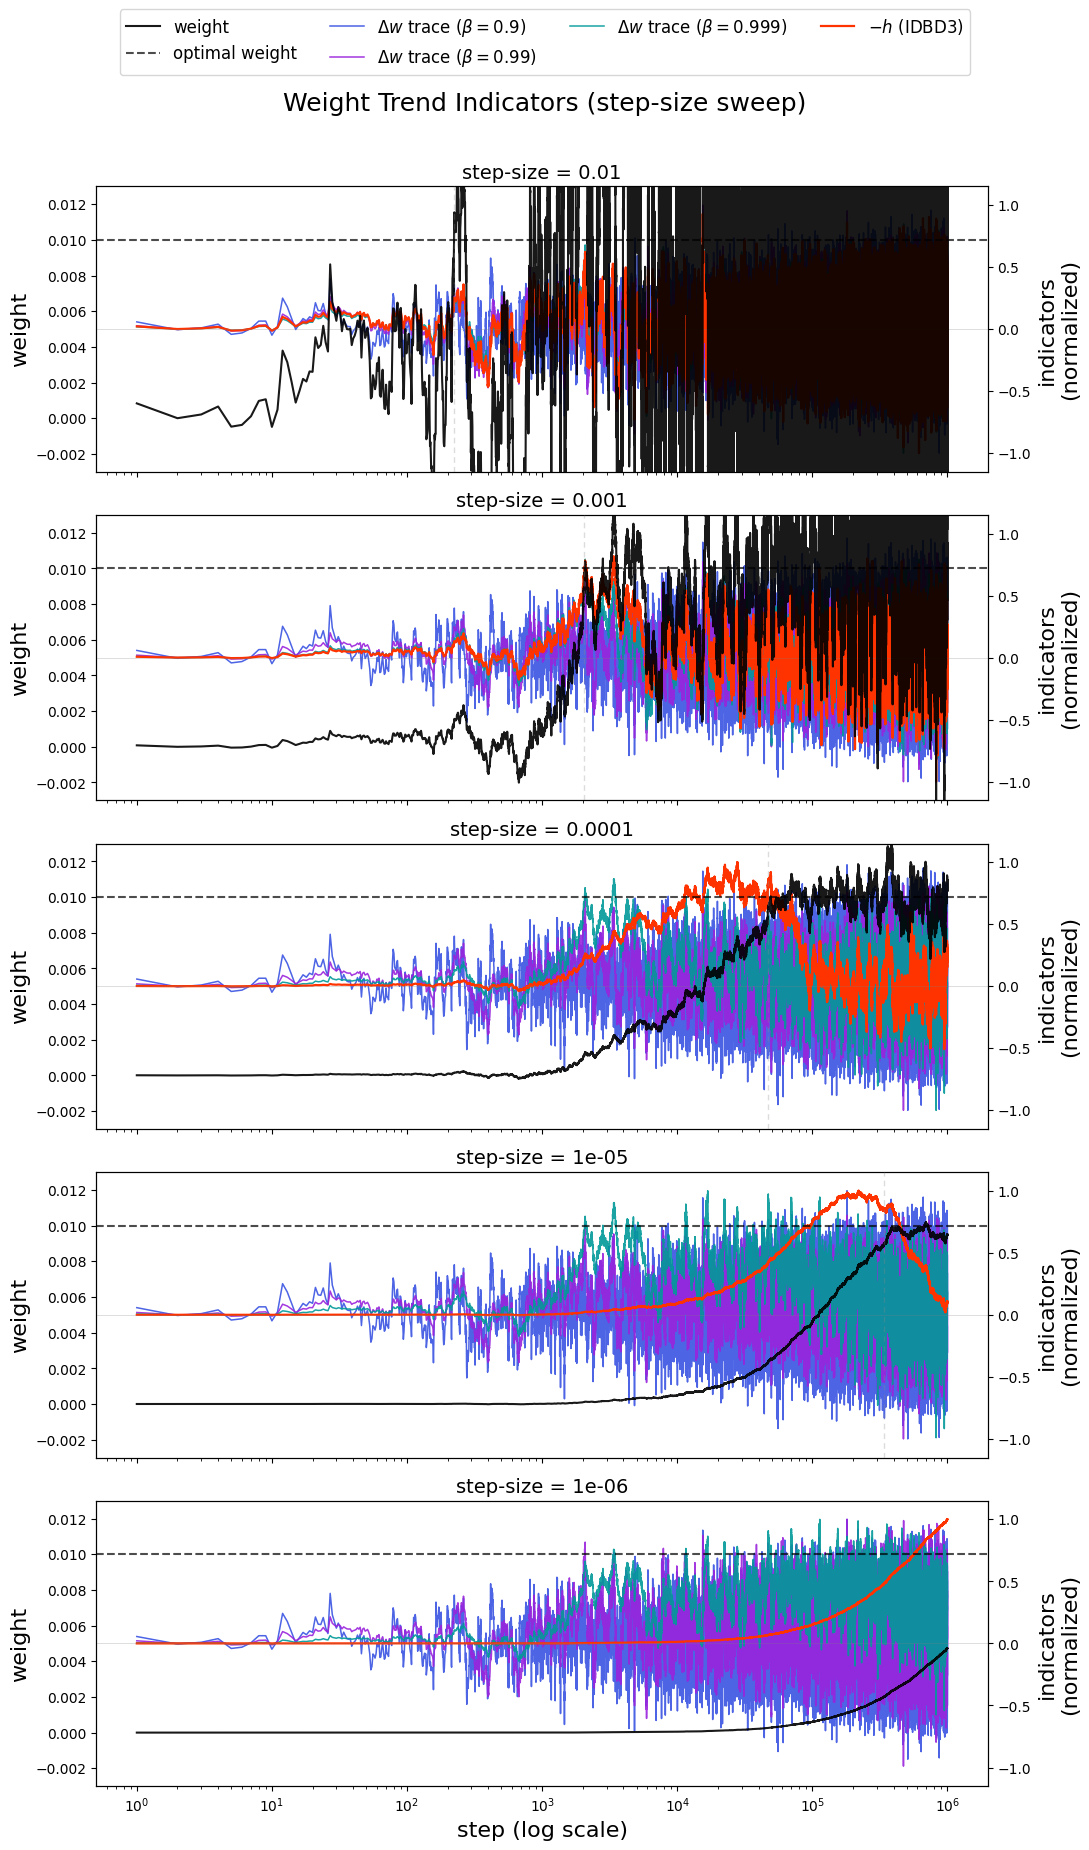

In [23]:
plot_steps = np.arange(1, n_steps + 1)
w_opt = optimal_weight(OPT_WEIGHT_SS, 0.0)   # clean feature -> equals 0.001
fig, axes = plt.subplots(len(STEP_SIZES), 1,
                         figsize=(11, 3.6 * len(STEP_SIZES)), sharex=True)
ax2_first = None
for ax, ss in zip(axes, STEP_SIZES[::-1]):
    res = results_ss[ss]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weight (true scale, black), now plotted after the right axis lines ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=1.5, label='weight', zorder=10, alpha=0.9)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'step-size = {ss:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through


    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (step-size sweep)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Third experiment: blocking by an established feature

Now there are **two colinear features** — two noisy views of the *same* signal
(`shared_signal=True`), differing only in their noise:

- **Established feature** — pre-trained: its weight starts at the value that is
  optimal when it is the *only* feature present, $w^*_{\text{est}} =
  \text{optimal\_weight}(w^*, c_{\text{est}})$. Its noise $c_{\text{est}}$ is the
  swept variable (one panel each: $1.0, 0.5, 0.1, 0.01, 0.0$).
- **Incumbent feature** — the tracked feature from the earlier experiments: clean
  ($c = 0$), learned from a zero weight. It now has to compete with the
  established feature for the shared signal.

Because the established feature already explains part of the target, we expect it
to **partially block** the incumbent — the cleaner (lower-noise) the established
feature, the more it blocks, so the incumbent's weight settles further below its
solo optimum $w^*$ (the dashed reference).

Same plot as before, tracked on the **incumbent** feature, with one addition: a
**partially transparent** line for the established feature's weight.


In [24]:
# ---------------------------------------------------------------------------
# Third experiment: a *blocking* setup. Two colinear features (shared_signal),
# i.e. two noisy views of the SAME underlying signal, differing only in noise:
#   - established feature (column 0): pre-trained, weight initialised at the
#     value that is optimal when it is the ONLY feature present,
#     optimal_weight(W_TEACHER, c_est). Its noise c_est is what we sweep.
#   - incumbent feature  (column 1, the tracked one): clean (noise 0), learned
#     from a zero weight -- exactly the feature studied before, but now it has to
#     compete with the established feature for the shared signal.
# Shared signal -> the teacher target is W_TEACHER * s + noise regardless of how
# the teacher weight is split across columns, so we put it all on column 0
# ([W_TEACHER, 0.0]); the incumbent's solo optimum is still
# optimal_weight(W_TEACHER, 0) == W_TEACHER (the dashed reference). How far the
# established feature blocks the incumbent below that reference is the thing to
# watch. Run function, step-size, indicators and noise are as in the first
# experiment; the step count gets its own value below.
# ---------------------------------------------------------------------------

W_TEACHER = 0.5                              # teacher weight on the shared signal
INCUMBENT_NOISE = 0.0                        # incumbent (learns from scratch) is clean
EST_NOISES = [1.0, 0.5, 0.1, 0.01, 0.0]      # swept: noise of the established feature
N_STEPS_BLOCK = 500_000                      # training steps for this experiment

results_block = {}
for c_est in EST_NOISES:
    # column 0 = established feature (noise c_est), column 1 = incumbent (clean, tracked)
    feats, targ = make_problem_data(
        N_STEPS_BLOCK, [W_TEACHER, 0.0], feature_noise=[c_est, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0,
    )
    w_est0 = optimal_weight(W_TEACHER, c_est)   # established weight starts at its solo optimum
    results_block[c_est] = run_lms_with_indicators(
        feats, targ, step_size=STEP_SIZE, w_init=[w_est0, 0.0])


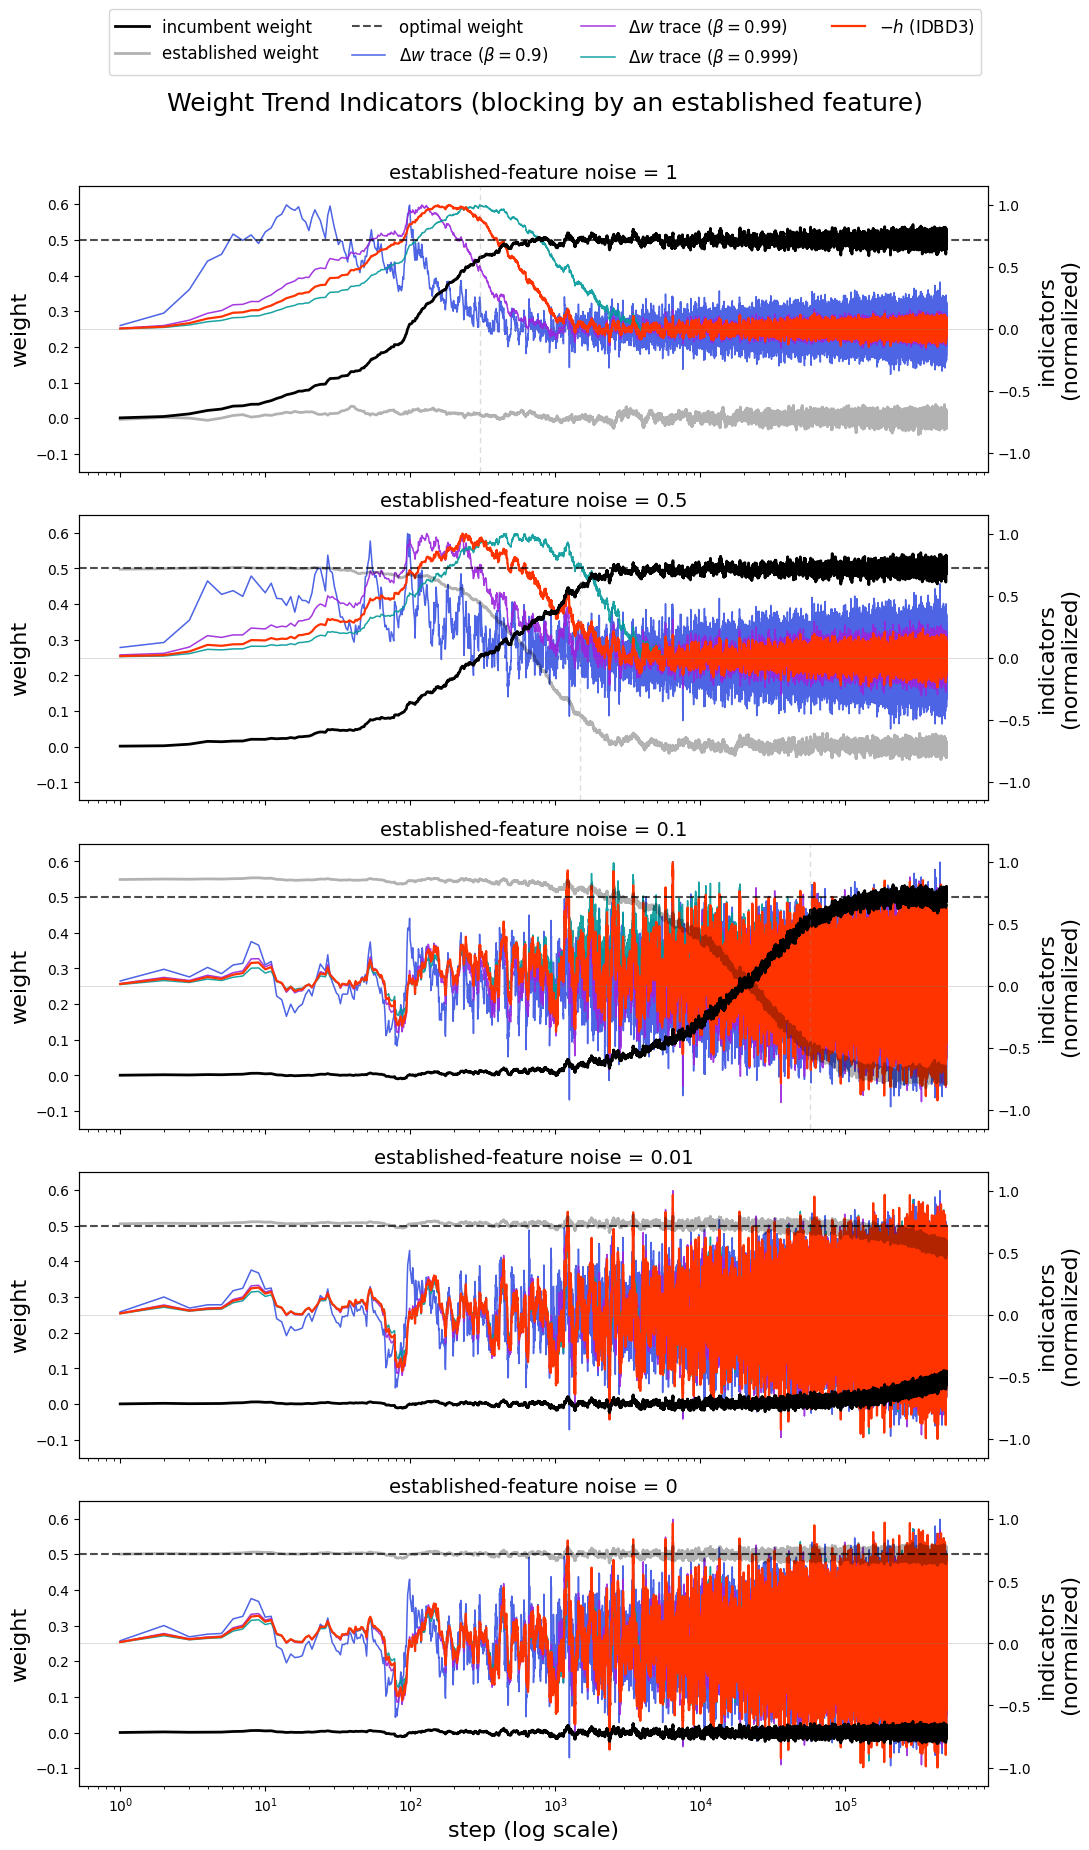

In [25]:
plot_steps = np.arange(1, N_STEPS_BLOCK + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(len(EST_NOISES), 1,
                         figsize=(11, 3.6 * len(EST_NOISES)), sharex=True)
ax2_first = None
for ax, c_est in zip(axes, EST_NOISES):
    res = results_block[c_est]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weights (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    # the established feature's weight: same scale, partially transparent
    ax.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'established-feature noise = {c_est:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: incumbent first reaches 90% of its solo optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (blocking by an established feature)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Fourth experiment: blocking, sweeping the step-size (established noise fixed at 0.1)

The same jump we made from the first experiment to the second, now applied to the
blocking setup. The established feature's noise is held fixed at $c_{\text{est}} =
0.1$ — so its weight starts at its solo optimum $w^\star_{\text{est}} =
\text{optimal\_weight}(0.5, 0.1) \approx 0.549$ — and the constant LMS / IDBD
step-size is swept instead. One panel per step-size; the incumbent is still clean
and learned from a zero weight, so its dashed solo optimum stays at $0.5$. The
partially transparent established-weight line is kept from the third experiment.


In [26]:
# ---------------------------------------------------------------------------
# Fourth experiment: the step-size sweep of the blocking setup -- the same jump
# we made from the first experiment to the second, now applied to the third. We
# fix the established feature's noise at 0.1 (so its solo optimum, where its
# weight starts, is optimal_weight(0.5, 0.1) ~= 0.549) and sweep the constant
# LMS / IDBD step-size instead. The incumbent is still clean and learned from a
# zero weight, and the teacher weight on the shared signal is unchanged
# (W_TEACHER = 0.5, so the incumbent's dashed solo optimum stays at 0.5). One
# panel per step-size.
# ---------------------------------------------------------------------------

EST_NOISE_FIXED = 0.1                          # held fixed (was the swept variable in exp 3)
STEP_SIZES_BLOCK = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
N_STEPS_BLOCK_SS = 500_000

w_est0 = optimal_weight(W_TEACHER, EST_NOISE_FIXED)   # established starts at its solo optimum

results_block_ss = {}
for ss in STEP_SIZES_BLOCK:
    # column 0 = established feature (noise EST_NOISE_FIXED), column 1 = incumbent (clean, tracked)
    feats, targ = make_problem_data(
        N_STEPS_BLOCK_SS, [W_TEACHER, 0.0], feature_noise=[EST_NOISE_FIXED, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0,
    )
    results_block_ss[ss] = run_lms_with_indicators(
        feats, targ, step_size=ss, w_init=[w_est0, 0.0])


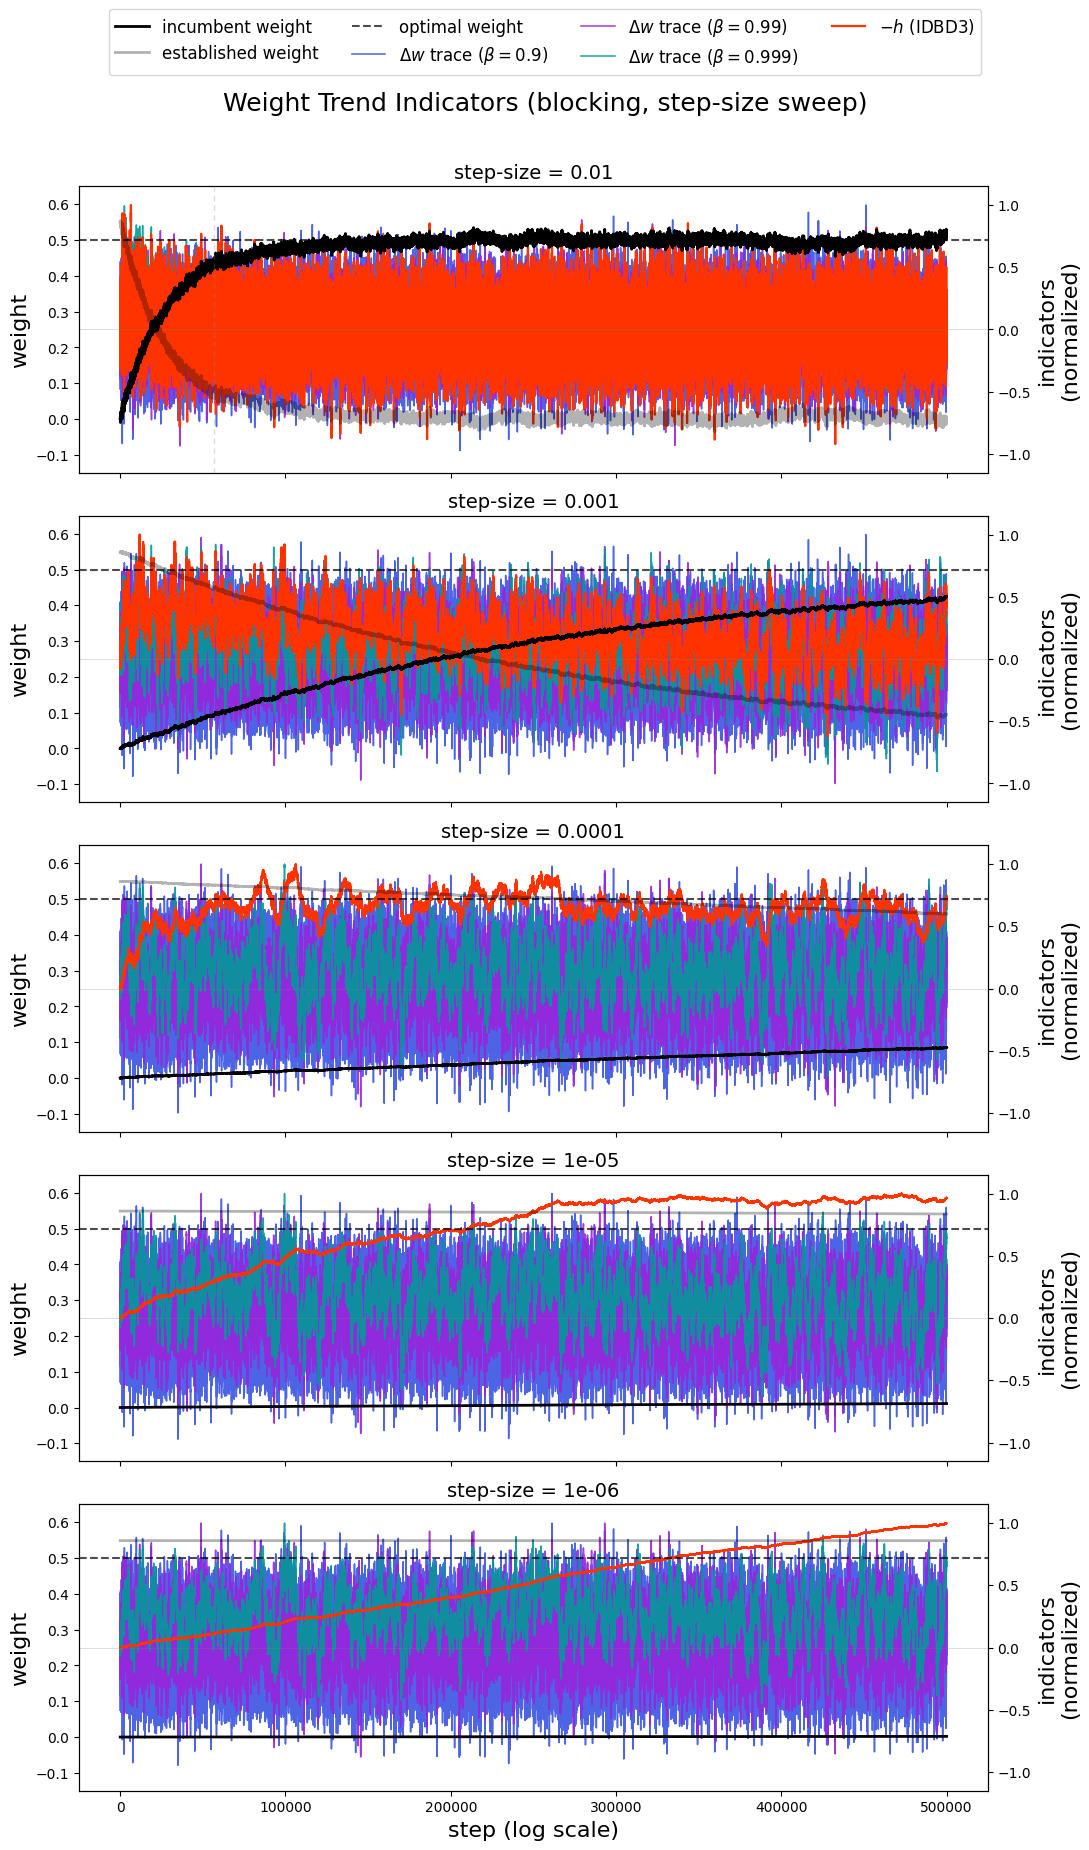

In [27]:
plot_steps = np.arange(1, N_STEPS_BLOCK_SS + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(len(STEP_SIZES_BLOCK), 1,
                         figsize=(11, 3.6 * len(STEP_SIZES_BLOCK)), sharex=True)
ax2_first = None
for ax, ss in zip(axes, STEP_SIZES_BLOCK[::-1]):
    res = results_block_ss[ss]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weights (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    # the established feature's weight: same scale, partially transparent
    ax.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    # ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'step-size = {ss:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: incumbent first reaches 90% of its solo optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (blocking, step-size sweep)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Fifth experiment: blocking learned with IDBD3 (meta-step-size 0.003)

Exactly the fourth experiment's blocking setup (two colinear features, established
noise fixed at $c_{\text{est}} = 0.1$, clean incumbent learned from zero,
$W_{\text{teacher}} = 0.5$), but learning now uses the project's **IDBD3**
optimiser (`optax_idbd3`, prediction-grads version) instead of constant-step-size
LMS. Each weight carries its own adaptive step-size $\alpha = e^{\beta}$, updated
with meta-step-size $\eta = 0.003$; the **swept** quantity is now the *initial*
step-size $\alpha_0$ (one panel each).

Because IDBD3 adapts the step-size, the previously *observed* $-h$ indicator is now
the optimiser's own running $h$-trace. In this linear case the prediction gradient
is just the input, so the $h$-decay term is $x^2$, and per weight each step:

$$\beta \leftarrow \beta + \eta\, x\, h, \qquad \alpha = e^{\beta}, \qquad
h \leftarrow h\,[\,1 - \alpha x^2\,]_+ + 2\,\text{err}\,x, \qquad
w \leftarrow w - \alpha\,(2\,\text{err}\,x),$$

with $\beta_0 = \log \alpha_0$. The partially transparent established-weight line is
kept from the previous experiments.


In [28]:
# ---------------------------------------------------------------------------
# Fifth experiment: the fourth experiment's blocking setup, but learned with the
# project's IDBD3 optimiser (optax_idbd3, prediction-grads version) instead of
# constant-step-size LMS. Each weight has its own adaptive step-size
# alpha = exp(beta), updated with meta-step-size META_LR_IDBD3; the swept quantity
# is now the INITIAL step-size (init_lr). The established / incumbent setup is
# unchanged from experiment 4 (W_TEACHER, INCUMBENT_NOISE, EST_NOISE_FIXED reused).
#
# Per weight, per step (prediction grads -> h-decay term is x**2):
#   loss_grad = 2*error*x ;  pred_grad = x ;  d = x**2
#   beta  <- beta + meta_lr * pred_grad * h          (project IDBD3 meta-update)
#   alpha = exp(beta)
#   h     <- h * max(1 - alpha*d, 0) + loss_grad     (IDBD3: no alpha on the add term)
#   w     <- w - alpha * loss_grad
# The h-trace is now the optimiser's own running h (it used to be observed-only).
# ---------------------------------------------------------------------------

META_LR_IDBD3 = 0.003
INIT_STEP_SIZES = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]   # swept: the INITIAL step-size (alpha_0)
N_STEPS_IDBD3 = 500_000


def run_idbd3_with_indicators(features, y, meta_lr, init_lr,
                              trace_decays=TRACE_DECAYS, w_init=None):
    """Learn with IDBD3 (prediction-grads version, so the h-decay term is x**2)
    over `features` (n_steps, n_feat). Per-weight step-sizes alpha = exp(beta)
    adapt with meta-step-size `meta_lr`, all starting at `init_lr`. The h-trace and
    dw traces are tracked for the LAST column (the feature under study). Outputs
    mirror run_lms_with_indicators (plus 'alpha'); `w_init` defaults to zeros."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.array(w_init, dtype=float)
    beta = np.full(n_feat, np.log(init_lr))     # per-weight log step-size
    h = np.zeros(n_feat)                          # per-weight IDBD3 gradient trace
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd3_hist = np.empty(n_steps)
    alpha_hist = np.empty((n_steps, n_feat))

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)
        loss_grad = error * f                    # dL/dw      (per weight)
        pred_grad = f                            # dy_hat/dw = x   (prediction grads)
        decay_term = f * f                       # x**2

        # IDBD3 meta-update (prediction grad * h, project convention)
        beta = beta + meta_lr * pred_grad * h
        alpha = np.exp(beta)

        # IDBD3 h-trace: no alpha factor on the additive loss-grad term
        h = h * np.clip(1.0 - alpha * decay_term, 0.0, None) + loss_grad

        # adaptive-step-size weight update for every weight
        dw = -alpha * loss_grad
        w = w + dw

        # EMA traces of the tracked weight's changes
        dw_tr = decays * dw_tr + (1.0 - decays) * dw[tracked]

        w_hist[t] = w
        dw_trace_hist[t] = dw_tr
        h_idbd3_hist[t] = h[tracked]
        alpha_hist[t] = alpha

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'h_idbd3': h_idbd3_hist, 'alpha': alpha_hist}


w_est0 = optimal_weight(W_TEACHER, EST_NOISE_FIXED)   # established starts at its solo optimum

results_idbd3 = {}
for ss in INIT_STEP_SIZES:
    # column 0 = established feature (noise EST_NOISE_FIXED), column 1 = incumbent (clean, tracked)
    feats, targ = make_problem_data(
        N_STEPS_IDBD3, [W_TEACHER, 0.0], feature_noise=[EST_NOISE_FIXED, INCUMBENT_NOISE],
        target_noise_std=0.1, shared_signal=True, seed=0,
    )
    results_idbd3[ss] = run_idbd3_with_indicators(
        feats, targ, meta_lr=META_LR_IDBD3, init_lr=ss, w_init=[w_est0, 0.0])


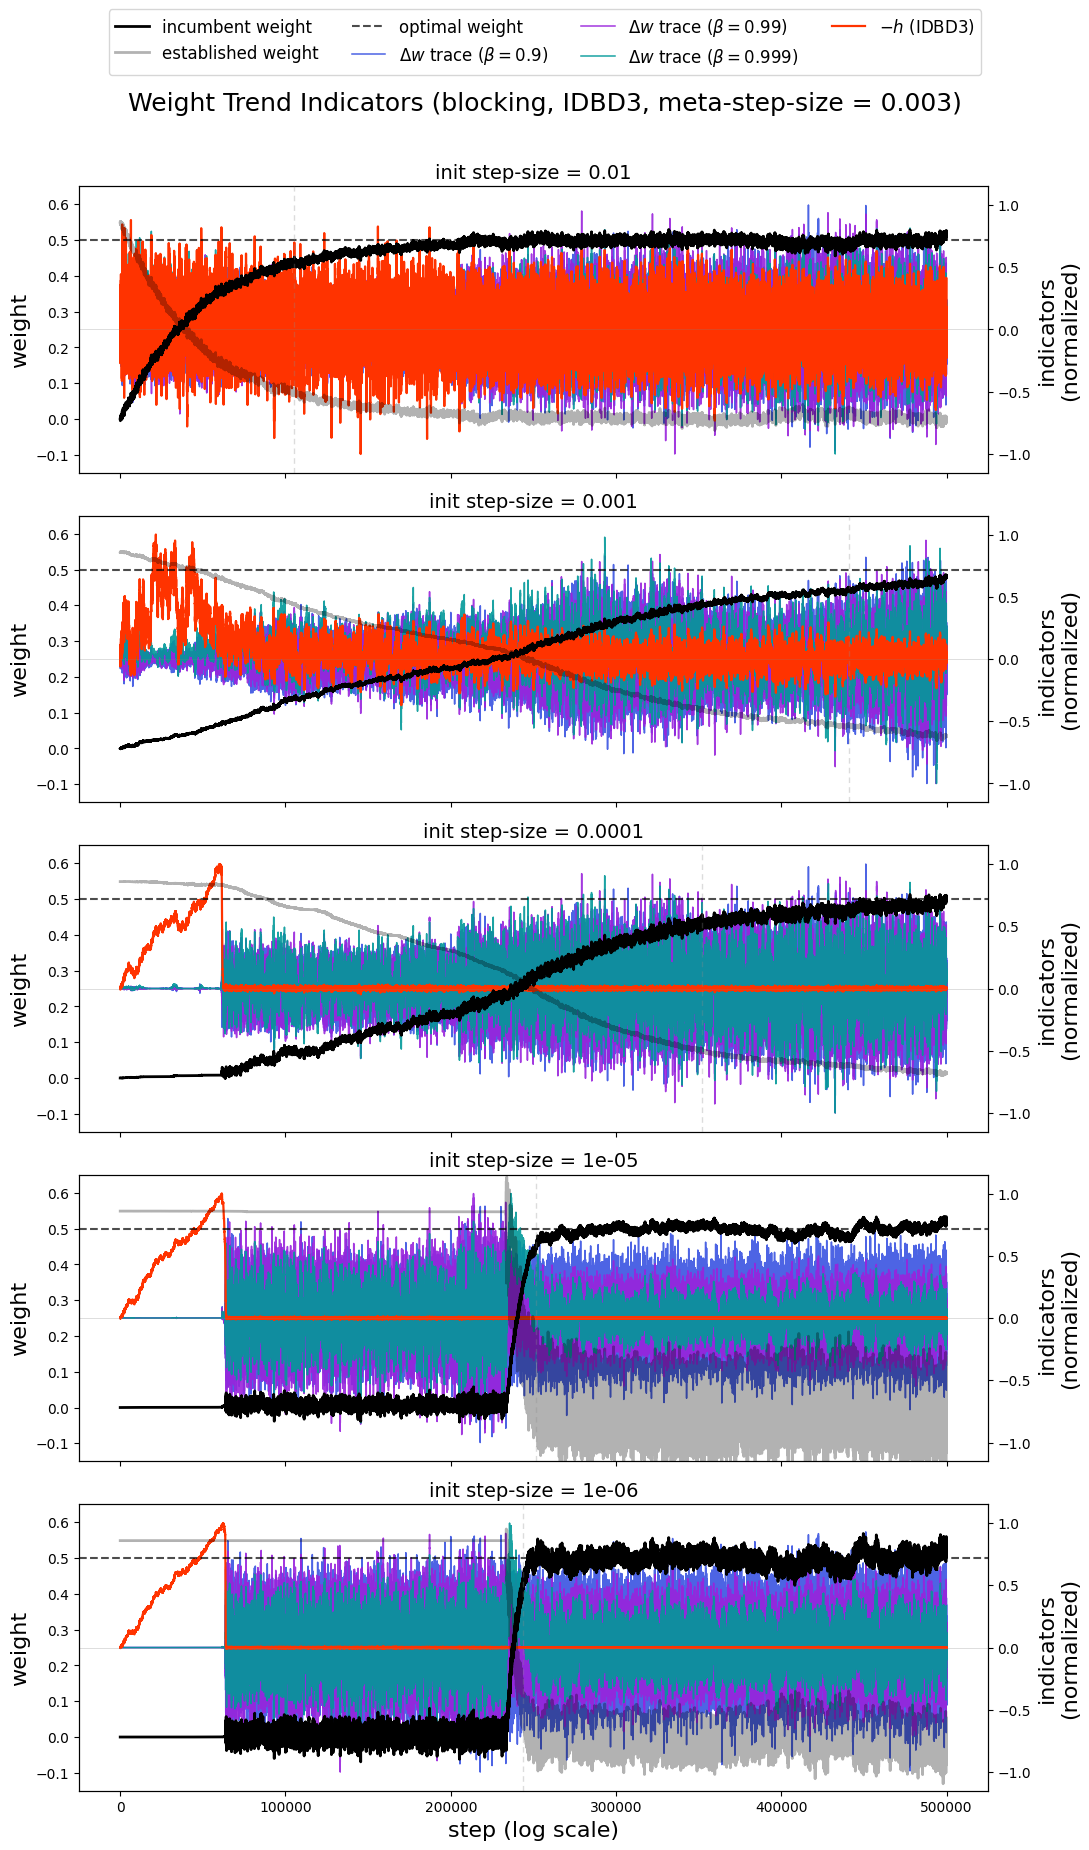

In [29]:
plot_steps = np.arange(1, N_STEPS_IDBD3 + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(len(INIT_STEP_SIZES), 1,
                         figsize=(11, 3.6 * len(INIT_STEP_SIZES)), sharex=True)
ax2_first = None
for ax, ss in zip(axes, INIT_STEP_SIZES[::-1]):
    res = results_idbd3[ss]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weights (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0,
            label='incumbent weight', zorder=10)
    # the established feature's weight: same scale, partially transparent
    ax.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
            label='established weight', zorder=10)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    # ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'init step-size = {ss:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: incumbent first reaches 90% of its solo optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle(f'Weight Trend Indicators (blocking, IDBD3, meta-step-size = {META_LR_IDBD3})', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Fifth experiment, diagnostic: chasing the jumps at small initial step-sizes

For initial step-sizes of $10^{-4}$ and below, the incumbent weight and the IDBD3
$h$-trace develop sudden, step-like jumps. As a first step toward explaining them
this dissects a **single** init-step-size run (default $\alpha_0 = 10^{-5}$; change
`DIAG_INIT_SS`). Two changes from the experiment-5 plot: drop the $\Delta w$ traces
so only the IDBD3 $h$ remains, and add the adaptive step-size $\alpha = e^{\beta}$
itself over the run (log scale). It reuses the runs already computed above
(`results_idbd3`) -- no re-training.

A mechanism to look for in the step-size panel: with a tiny $\alpha$ the decay
factor $[\,1 - \alpha x^2\,]_+ \approx 1$, so $h$ barely decays and instead
**accumulates** the loss-gradient nearly undamped. That growing $h$ drives
$\beta \leftarrow \beta + \eta\, x\, h$, so $\alpha$ climbs -- until $\alpha x^2$
finally becomes $O(1)$, at which point $h$ decays/clips and $\alpha$ and the weight
lurch within a few steps. If that is what is happening, the jumps in $w$ and $h$
should line up with $\alpha$ crossing into the $\alpha x^2 \sim 1$ regime.

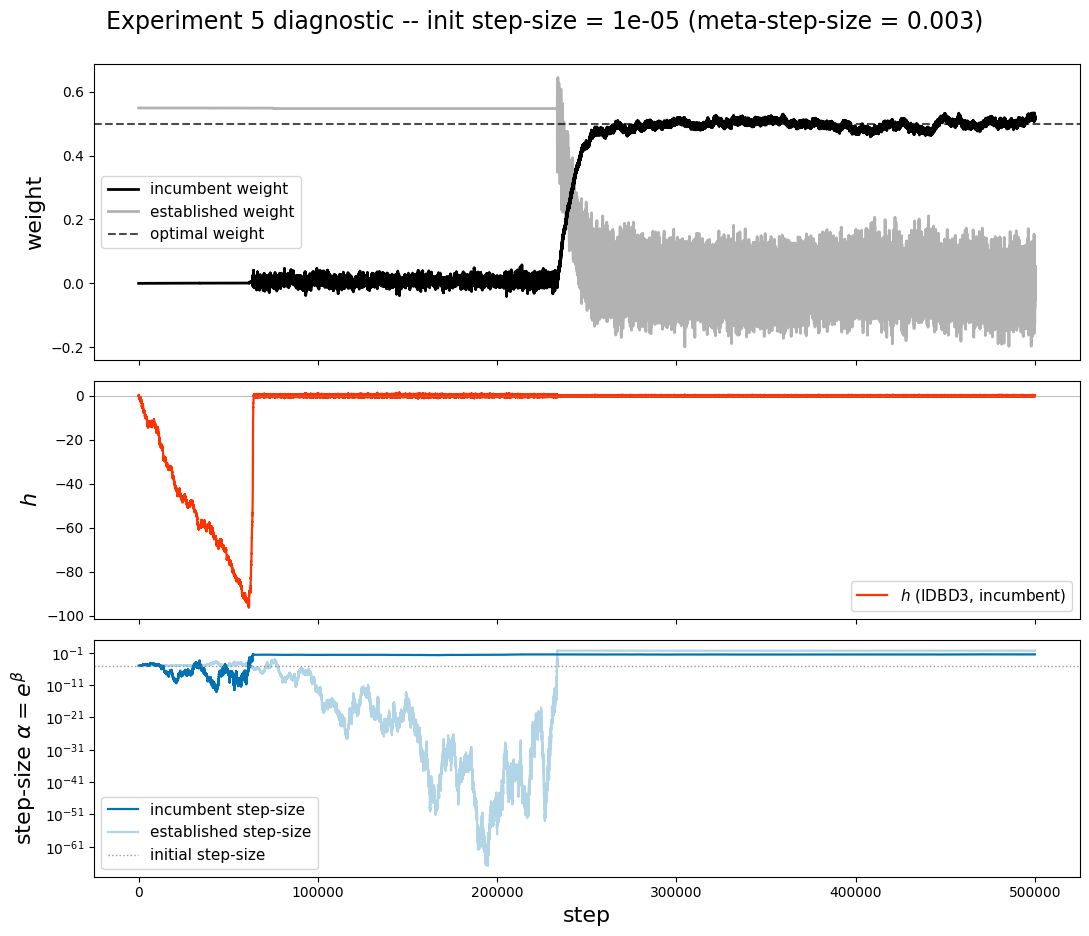

In [30]:
# ---------------------------------------------------------------------------
# Fifth experiment, diagnostic: zoom in on ONE init-step-size run to chase the
# sudden jumps in the weight and the h-trace that show up for small initial
# step-sizes (1e-4 and below). Two changes from the experiment-5 plot:
#   (1) drop the dw-traces -- keep only the IDBD3 h indicator, and
#   (2) add the adaptive step-size alpha = exp(beta) over the run (log scale).
# Reuses the runs already computed above (results_idbd3); no re-training.
# NOTE: h and the tracked step-size are for the incumbent (last column, the
# feature under study); the established weight's alpha is shown transparently.
# ---------------------------------------------------------------------------

DIAG_INIT_SS = 1e-5          # which run to dissect (must be one of INIT_STEP_SIZES)
DIAG_SS_COLOR = '#0072B2'    # blue: distinct from weight (black) and h (orange)

res = results_idbd3[DIAG_INIT_SS]
plot_steps = np.arange(1, N_STEPS_IDBD3 + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER

fig, (ax_w, ax_h, ax_a) = plt.subplots(
    3, 1, figsize=(11, 9.5), sharex=True,
    gridspec_kw={'height_ratios': [1.25, 1.0, 1.0]})

# --- (1) weights, true scale ---
ax_w.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='incumbent weight')
ax_w.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
          label='established weight')
ax_w.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
ax_w.set_ylabel('weight', fontsize=16)
ax_w.legend(fontsize=11, loc='best')

# --- (2) IDBD3 h-trace, raw & signed (incumbent only) ---
ax_h.plot(plot_steps, res['h_idbd3'], color=H_IDBD3_COLOR, lw=1.6,
          label='$h$ (IDBD3, incumbent)')
ax_h.axhline(0.0, color='0.5', lw=0.8, alpha=0.5)
ax_h.set_ylabel('$h$', fontsize=16)
ax_h.legend(fontsize=11, loc='best')

# --- (3) adaptive step-size alpha = exp(beta), log scale ---
ax_a.plot(plot_steps, res['alpha'][:, -1], color=DIAG_SS_COLOR, lw=1.6,
          label='incumbent step-size')
ax_a.plot(plot_steps, res['alpha'][:, 0], color=DIAG_SS_COLOR, lw=1.6, alpha=0.3,
          label='established step-size')
ax_a.axhline(DIAG_INIT_SS, color='0.5', ls=':', lw=1.0, alpha=0.8,
             label='initial step-size')
ax_a.set_yscale('log')
ax_a.set_ylabel(r'step-size $\alpha = e^{\beta}$', fontsize=16)
ax_a.set_xlabel('step', fontsize=16)
ax_a.legend(fontsize=11, loc='best')

fig.suptitle(f'Experiment 5 diagnostic -- init step-size = {DIAG_INIT_SS:.3g} '
             f'(meta-step-size = {META_LR_IDBD3})', fontsize=17)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### Fifth experiment, diagnostic (cont.): IDBD vs IDBD3 vs Autostep

The same single-run diagnostic (blocking setup, one init step-size, default
$\alpha_0 = 10^{-5}$), now for the three step-size rules from the project's
`optax_idbd`, so we can see which of them produces the sudden jumps. **Prediction
grads throughout**, so the $h$-decay term is $x^2$ for every rule. Squared-error
loss with $\text{loss\_grad} = \text{err}\cdot x$ (matches experiment 5). The rules
differ only in how $\alpha = e^{\beta}$ and $h$ are updated per weight:

- **IDBD** &nbsp; $\beta \leftarrow \beta + \eta\, x\, h$, &nbsp;
  $h \leftarrow h\,[\,1 - \alpha x^2\,]_+ + \alpha\,\text{loss\_grad}$
  &nbsp;(the $h$ add-term *is* scaled by $\alpha$).
- **IDBD3** &nbsp; same $\beta$ update, but
  $h \leftarrow h\,[\,1 - \alpha x^2\,]_+ + \text{loss\_grad}$
  &nbsp;(no $\alpha$ on the add-term -- the experiment-5 rule).
- **Autostep** &nbsp; normalised meta-update
  $v \leftarrow \max\!\big(|h\,\text{loss\_grad}|,\; v + \tfrac{1}{\tau}\alpha x^2(|h\,\text{loss\_grad}| - v)\big)$,
  $\alpha \leftarrow \alpha\,\exp\!\big(\eta\, h\,\text{loss\_grad}/v\big)$, then the
  per-layer effective-step-size cap $\alpha \leftarrow \alpha / \max\!\big(\sum_j \alpha_j x_j^2,\, 1\big)$;
  its $h$ update matches IDBD ($\alpha\,\text{loss\_grad}$ add-term).

As before we drop the $\Delta w$ traces (rows are weight / $h$ / step-size $\alpha$;
columns are the three rules; $h$ and the tracked $\alpha$ are the incumbent's). The
per-rule meta-step-sizes in `COMPARE_ALGOS` and `COMPARE_TAU` are the tunable knobs.
This trains three fresh 500k-step runs, so it is a touch slow.

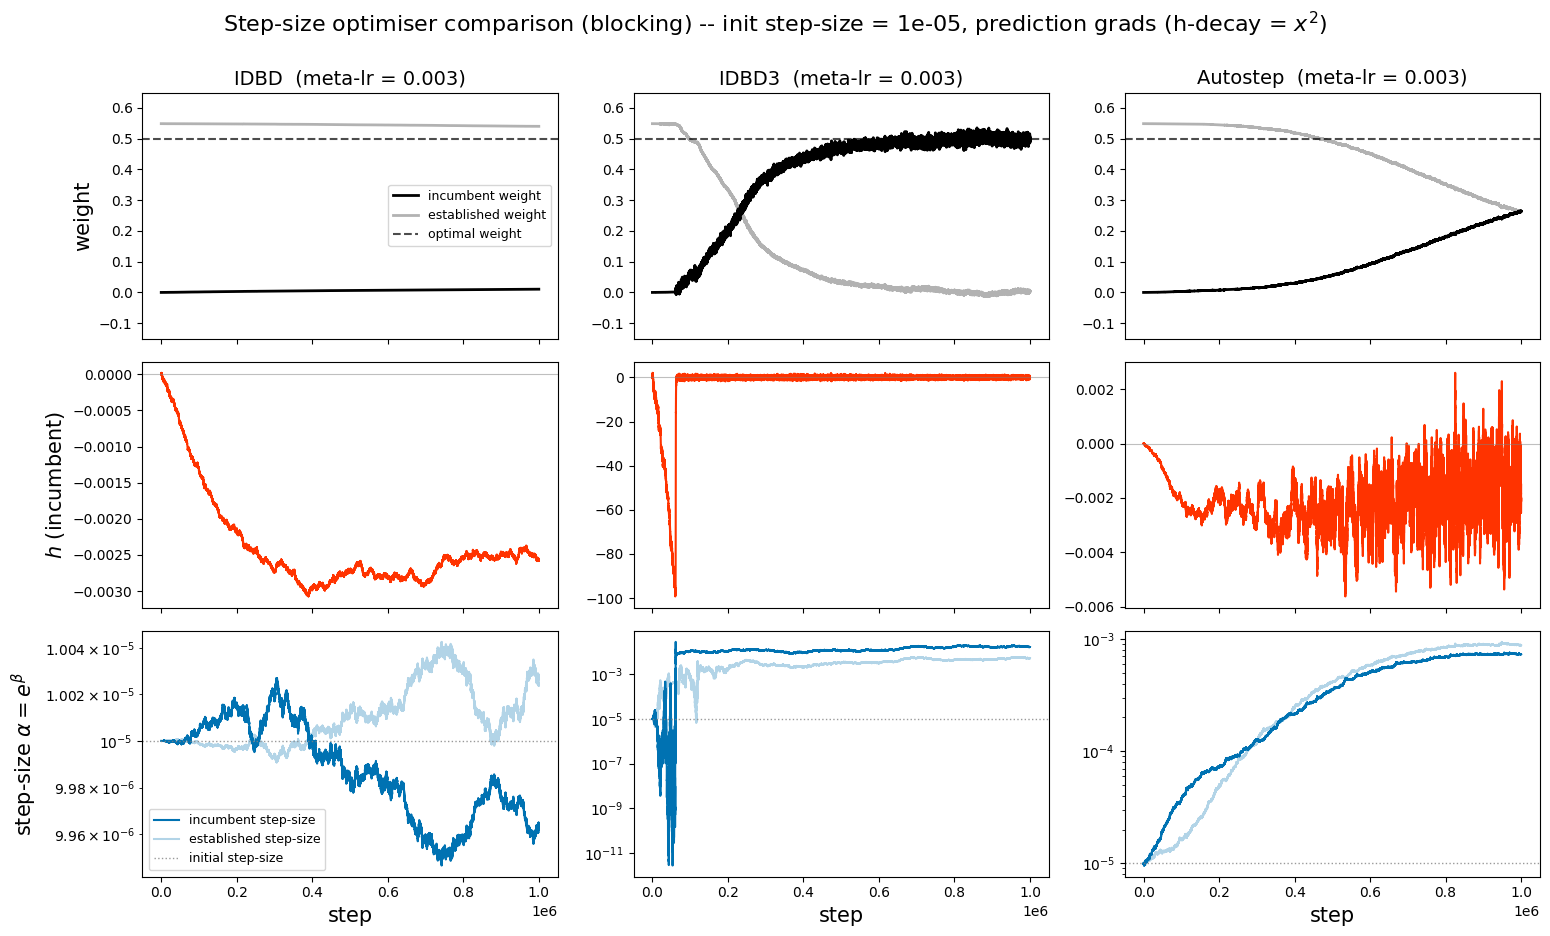

In [31]:
# ---------------------------------------------------------------------------
# Fifth experiment, diagnostic (cont.): the SAME single-run diagnostic, run with
# each of the three step-size rules in the project's optax_idbd -- IDBD, IDBD3,
# and Autostep -- so we can see which one produces the sudden jumps. Prediction
# grads throughout (h-decay term = x**2); squared-error loss with
# loss_grad = err * x (matches experiment 5). The rules differ only in the
# alpha / h update; see run_stepsize_opt_with_indicators below. Trains three
# fresh runs (no reuse of results_idbd3), so it is a bit slow.
# ---------------------------------------------------------------------------

COMPARE_INIT_SS = 1e-5                      # init step-size to dissect (all rules)
COMPARE_TAU = 1e4                           # Autostep v-tracker time constant
COMPARE_ALGOS = [                           # (algo key, display title, meta-step-size)
    ('idbd',     'IDBD',     0.003),
    ('idbd3',    'IDBD3',    0.003),        # == experiment 5
    ('autostep', 'Autostep', 0.003),         # Autostep's meta-lr is multiplicative
]
SS_COLOR = '#0072B2'                        # blue: distinct from weight (black) / h (orange)


def run_stepsize_opt_with_indicators(features, y, algo, meta_lr, init_lr,
                                     tau=1e4, w_init=None):
    """Adaptive per-weight step-size learning over `features` (n_steps, n_feat),
    reimplementing the project's optax_idbd for `algo` in
    {'idbd', 'idbd3', 'autostep'}. Prediction grads throughout, so the h-decay
    term is x**2; squared-error loss_grad = err * x (experiment-5 convention).
    Per-weight step-size alpha = exp(beta) starts at `init_lr` and the gradient
    trace h at 0; `w_init` defaults to zeros. Tracks alpha and h for EVERY weight.
    The 'idbd3' branch is identical to run_idbd3_with_indicators. Returns
    {'w', 'h', 'alpha'}, each (n_steps, n_feat)."""
    assert algo in ('idbd', 'idbd3', 'autostep'), f'unknown algo {algo!r}'
    n_steps, n_feat = features.shape

    w = np.zeros(n_feat) if w_init is None else np.array(w_init, dtype=float)
    beta = np.full(n_feat, np.log(init_lr))      # per-weight log step-size
    h = np.zeros(n_feat)                          # per-weight gradient trace
    v = np.zeros(n_feat)                          # Autostep normaliser (else unused)

    w_hist = np.empty((n_steps, n_feat))
    h_hist = np.empty((n_steps, n_feat))
    alpha_hist = np.empty((n_steps, n_feat))

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]               # y_hat - y  (project convention)
        loss_grad = error * f                     # dL/dw       (0.5*err**2 convention)
        d = f * f                                 # prediction-grad squared (x**2)

        if algo == 'autostep':
            alpha = np.exp(beta)
            gh = h * loss_grad
            v = np.maximum(np.abs(gh),
                           v + (1.0 / tau) * alpha * d * (np.abs(gh) - v))
            safe_v = np.where(v != 0.0, v, 1.0)   # guard the v == 0 warm-up steps
            alpha = np.where(v != 0.0, alpha * np.exp(meta_lr * gh / safe_v), alpha)
            # per-layer effective-step-size cap (sum over the linear layer's inputs)
            alpha = alpha / max(np.sum(alpha * d), 1.0)
            beta = np.log(alpha)
        else:
            beta = beta + meta_lr * f * h         # IDBD / IDBD3 meta-update (pred-grad * h)
            alpha = np.exp(beta)

        # h-trace: IDBD & Autostep scale the additive term by alpha; IDBD3 does not
        add_term = loss_grad if algo == 'idbd3' else alpha * loss_grad
        h = h * np.clip(1.0 - alpha * d, 0.0, None) + add_term

        w = w - alpha * loss_grad                 # weight update (weight_decay = 0)

        w_hist[t] = w
        h_hist[t] = h
        alpha_hist[t] = alpha

    return {'w': w_hist, 'h': h_hist, 'alpha': alpha_hist}


N_STEPS = int(1e6)
# column 0 = established feature (noise EST_NOISE_FIXED), column 1 = incumbent (clean, tracked)
feats_cmp, targ_cmp = make_problem_data(
    N_STEPS, [W_TEACHER, 0.0], feature_noise=[EST_NOISE_FIXED, INCUMBENT_NOISE],
    target_noise_std=0.1, shared_signal=True, seed=0,
)
w_est0 = optimal_weight(W_TEACHER, EST_NOISE_FIXED)   # established starts at its solo optimum

results_compare = {}
for _key, _title, _mlr in COMPARE_ALGOS:
    results_compare[_key] = run_stepsize_opt_with_indicators(
        feats_cmp, targ_cmp, algo=_key, meta_lr=_mlr, init_lr=COMPARE_INIT_SS,
        tau=COMPARE_TAU, w_init=[w_est0, 0.0])


plot_steps = np.arange(1, N_STEPS + 1)
w_opt = optimal_weight(W_TEACHER, INCUMBENT_NOISE)   # clean incumbent -> equals W_TEACHER
fig, axes = plt.subplots(3, len(COMPARE_ALGOS),
                         figsize=(5.2 * len(COMPARE_ALGOS), 9.5), sharex=True)
for col, (key, title, mlr) in enumerate(COMPARE_ALGOS):
    res = results_compare[key]
    ax_w, ax_h, ax_a = axes[0, col], axes[1, col], axes[2, col]

    # --- weights (true scale, shared ylim) ---
    ax_w.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='incumbent weight')
    ax_w.plot(plot_steps, res['w'][:, 0], color=W_COLOR, lw=2.0, alpha=0.3,
              label='established weight')
    ax_w.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
    ax_w.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax_w.set_title(f'{title}  (meta-lr = {mlr:g})', fontsize=14)

    # --- IDBD/IDBD3/Autostep h-trace, raw & signed (incumbent) ---
    ax_h.plot(plot_steps, res['h'][:, -1], color=H_IDBD3_COLOR, lw=1.5)
    ax_h.axhline(0.0, color='0.5', lw=0.8, alpha=0.5)

    # --- adaptive step-size alpha = exp(beta), log scale ---
    ax_a.plot(plot_steps, res['alpha'][:, -1], color=SS_COLOR, lw=1.5,
              label='incumbent step-size')
    ax_a.plot(plot_steps, res['alpha'][:, 0], color=SS_COLOR, lw=1.5, alpha=0.3,
              label='established step-size')
    ax_a.axhline(COMPARE_INIT_SS, color='0.5', ls=':', lw=1.0, alpha=0.8,
                 label='initial step-size')
    ax_a.set_yscale('log')
    ax_a.set_xlabel('step', fontsize=15)

    if col == 0:
        ax_w.set_ylabel('weight', fontsize=15)
        ax_h.set_ylabel('$h$ (incumbent)', fontsize=15)
        ax_a.set_ylabel(r'step-size $\alpha = e^{\beta}$', fontsize=15)
        ax_w.legend(fontsize=9, loc='center right')
        ax_a.legend(fontsize=9, loc='best')

fig.suptitle(f'Step-size optimiser comparison (blocking) -- init step-size '
             f'= {COMPARE_INIT_SS:.3g}, prediction grads (h-decay = $x^2$)', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### Sixth experiment: a single intermittently-useful feature

A single-feature variant of the third experiment. With only one feature there is
no *established* feature to do the blocking, so instead of sweeping the
established feature's noise we sweep **how often the one feature is useful**,
$p \in \{1, 0.5, 0.1, 0.01, 0.001\}$ (one panel each).

The feature is clean and learned from a zero weight — exactly the feature from
the first two experiments. On a random $(1-p)$ fraction of steps its *observed*
value is set to $0$, while the target is still built from the clean signal and is
**left untouched**; on those steps the feature simply carries no information
about an unchanged target. At $p = 1$ the feature is always on, so this is just a
single clean feature learned to $w^\star = 0.5$ — the third experiment's setup
minus the established feature. As $p$ shrinks the feature is informative less and
less often.

Zeroing the feature does **not** move the least-squares optimum: it scales both
$\mathrm{Cov}(f, y)$ and $\mathrm{Var}(f)$ by the same factor $p$, so
$w^\star = \mathrm{Cov}/\mathrm{Var} = 0.5$ for every $p$. The dashed
optimal-weight reference therefore stays at $0.5$ in every panel — only the
*speed and steadiness* of maturation (and hence the indicators) change.
Step-size ($0.01$), indicators, target noise ($0.1$) and step count ($500\text{k}$)
match the third experiment; same single weight line, axes and normalization.


In [32]:
# ---------------------------------------------------------------------------
# Sixth experiment: a single-feature variant of the third experiment. With only
# one feature there is no *established* feature to do the blocking, so instead of
# sweeping the established feature's noise we sweep how OFTEN the single feature
# is useful.
#
# The feature is clean and learned from a zero weight (exactly the feature from
# the first two experiments). On a random (1 - useful_freq) fraction of steps its
# OBSERVED value is set to 0; the target is still built from the clean signal and
# is left untouched, so on those steps the feature simply carries no information
# about an unchanged target. At useful_freq = 1 the feature is always on and this
# is just a single clean feature learned to w* = 0.5 -- the third experiment's
# setup minus the established feature; as useful_freq shrinks the feature is
# informative less and less often.
#
# The least-squares optimum is UNCHANGED by the masking: zeroing f on a fraction
# (1 - p) of steps scales Cov(f, y) and Var(f) by the same factor p, so
# w* = Cov/Var = OPT_WEIGHT_UF for every p. The dashed optimal-weight reference
# therefore stays put in every panel -- only the speed/steadiness of maturation
# (and hence the indicators) change. Step-size (STEP_SIZE = 0.01), indicators,
# target noise (0.1) and step count (500k) match the third experiment.
# ---------------------------------------------------------------------------

OPT_WEIGHT_UF = 0.5                          # teacher/optimal weight (as in experiment 3)
USEFUL_FREQS = [1.0, 0.5, 0.1, 0.01, 0.001]  # swept: fraction of steps the feature is useful
N_STEPS_UF = 500_000                         # matches the third experiment


def make_intermittent_data(n_steps, target_weight, useful_freq, *,
                           target_noise_std=0.1, seed=0):
    """Single clean feature whose OBSERVED value is zeroed on a random
    (1 - useful_freq) fraction of steps, leaving the target (built from the clean
    signal) untouched. useful_freq = 1 reproduces make_problem_data's single clean
    feature exactly. The mask uses its own RNG (seed + 1) so it is reproducible
    and independent of the signal/noise draws."""
    feats, targ = make_problem_data(n_steps, [target_weight], feature_noise=0.0,
                                    target_noise_std=target_noise_std, seed=seed)
    mask_rng = np.random.default_rng(seed + 1)
    inactive = mask_rng.uniform(size=n_steps) >= useful_freq
    feats[inactive, 0] = 0.0
    return feats, targ


results_uf = {}
for p in USEFUL_FREQS:
    # single clean feature, useful on a fraction p of steps; target noise = 0.1
    feats, targ = make_intermittent_data(N_STEPS_UF, OPT_WEIGHT_UF, p,
                                         target_noise_std=0.1, seed=0)
    results_uf[p] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


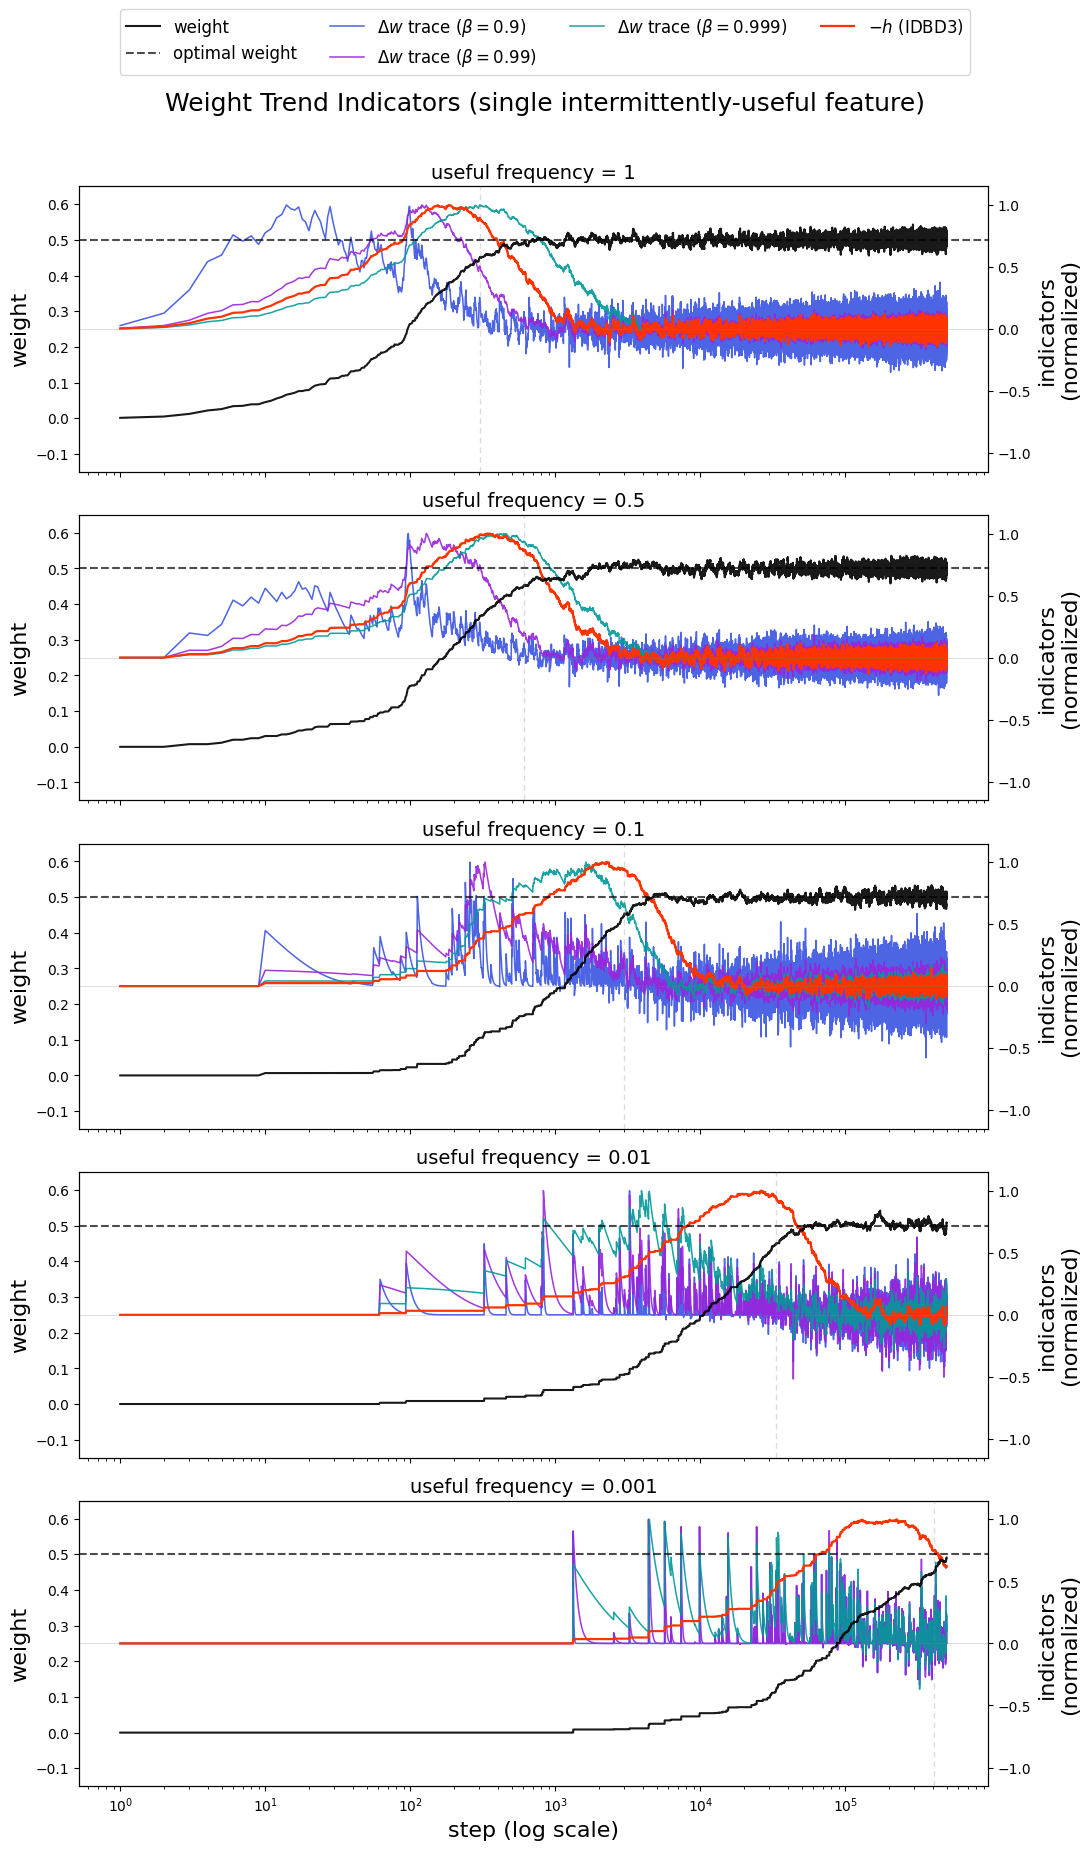

In [33]:
plot_steps = np.arange(1, N_STEPS_UF + 1)
w_opt = optimal_weight(OPT_WEIGHT_UF, 0.0)   # unaffected by the masking -> equals OPT_WEIGHT_UF
fig, axes = plt.subplots(len(USEFUL_FREQS), 1,
                         figsize=(11, 3.6 * len(USEFUL_FREQS)), sharex=True)
ax2_first = None
for ax, p in zip(axes, USEFUL_FREQS):
    res = results_uf[p]

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weight (true scale, black), plotted after the right axis lines ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=1.5, label='weight',
            zorder=10, alpha=0.9)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'useful frequency = {p:.3g}', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: weight first reaches 90% of its optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (single intermittently-useful feature)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Seventh experiment: a single feature that drops its signal (keeping its noise)

The sixth experiment again, but the feature now **carries noise** and it is the
*signal* — not the whole feature — that drops out. The feature is a noisy view
$f = (1-c)\,s + c\,u$ of the signal (noise coefficient $c = 0.1$). On a random
$(1-p)$ fraction of steps the signal part is removed while the noise part is
kept, so there $f = c\,u$ (pure noise); the target $y = 0.5\,s + \text{noise}$ is
still built from the clean signal and is **left untouched**. We sweep the signal
frequency $p \in \{1, 0.5, 0.1, 0.01, 0.001\}$ (one panel each).

Unlike the sixth experiment — which zeroed the *whole* feature on inactive steps,
freezing the weight ($f = 0 \Rightarrow$ no update) — the feature here keeps
emitting noise when it has no signal, so LMS **keeps updating from pure noise** on
those steps. Two consequences:

- the indicators never freeze during inactive stretches (the feature is never
  silent); and
- the least-squares optimum is **pulled toward zero** as the signal gets rarer,
  because the ever-present noise inflates $\mathrm{Var}(f)$ without adding any
  $\mathrm{Cov}(f, y)$:
  $$w^\star(p, c) = \frac{(1-c)\,w_{\text{teacher}}\,p}{(1-c)^2\,p + c^2},$$
  which equals $\text{optimal\_weight}(0.5, 0.1) \approx 0.549$ at $p = 1$ and
  $\to 0$ as $p \to 0$. The dashed optimal-weight reference therefore **differs
  per panel** (shown in each title), and the y-range is scaled to each panel's own
  optimum. Everything else matches the sixth experiment.


In [34]:
# ---------------------------------------------------------------------------
# Seventh experiment: the sixth experiment, but the feature now carries noise and
# it is the SIGNAL -- not the whole feature -- that drops out. The feature is a
# noisy view f = (1 - c) * s + c * u of the signal (c = FEATURE_NOISE_SD). On a
# random (1 - useful_freq) fraction of steps the signal part is removed while the
# noise part is kept, so on those steps f = c * u (pure noise); the target,
# y = W_TEACHER_SD * s + noise, is built from the clean signal and is left
# untouched, exactly as before.
#
# Contrast with the sixth experiment, which zeroed the WHOLE feature on inactive
# steps (f = 0 -> no gradient -> no weight update). Here the feature keeps
# emitting noise when it carries no signal, so LMS keeps updating from pure noise
# on those steps. Two consequences:
#   - the indicators no longer freeze during inactive stretches (the feature is
#     never silent), and
#   - the least-squares optimum is now pulled toward zero as the signal appears
#     less often, because the ever-present noise inflates Var(f) without adding
#     any Cov(f, y):
#         w*(p, c) = (1 - c) * W_TEACHER_SD * p / ((1 - c)**2 * p + c**2)
#     (= optimal_weight(W_TEACHER_SD, c) at p = 1, = W_TEACHER_SD at c = 0 -- the
#     sixth experiment). The dashed reference therefore differs per panel.
# Step-size, teacher weight, target noise and step count match the sixth experiment.
# ---------------------------------------------------------------------------

W_TEACHER_SD = 0.5                              # teacher weight on the clean signal (as in exp 3 & 6)
FEATURE_NOISE_SD = 0.1                           # feature noise coefficient c, kept even when the signal drops
USEFUL_FREQS_SD = [1.0, 0.5, 0.1, 0.01, 0.001]   # swept: fraction of steps the SIGNAL is present
N_STEPS_SD = 500_000                             # matches the sixth experiment


def make_signal_dropout_data(n_steps, target_weight, useful_freq, *,
                             feature_noise, target_noise_std=0.1, seed=0):
    """Single noisy feature f = (1 - c) * s + c * u whose SIGNAL part is dropped
    on a random (1 - useful_freq) fraction of steps while its NOISE part is kept:
    on those steps f = c * u (pure noise). The target y = target_weight * s + noise
    is built from the clean signal and is left untouched by the dropout.

    Draw order (signal, target noise, feature noise) matches make_problem_data, so
    useful_freq = 1 reproduces make_problem_data(n_steps, [target_weight],
    feature_noise=c) exactly. The mask uses its own RNG (seed + 1)."""
    rng = np.random.default_rng(seed)
    c = float(feature_noise)
    s = rng.uniform(-1.0, 1.0, size=n_steps)               # clean signal
    tn = rng.normal(0.0, target_noise_std, size=n_steps)   # target noise
    u = rng.uniform(-1.0, 1.0, size=n_steps)               # feature noise
    y = target_weight * s + tn                             # target: clean signal, untouched
    mask_rng = np.random.default_rng(seed + 1)
    active = mask_rng.uniform(size=n_steps) < useful_freq  # is the signal present this step?
    feats = ((1.0 - c) * s * active + c * u).reshape(-1, 1)
    return feats, y


def optimal_weight_dropout(target_weight, feature_noise, useful_freq):
    """Least-squares optimum for the signal-dropout feature: with the signal
    present on a fraction p of steps and noise c * u on every step,
        w* = Cov(f, y) / Var(f)
           = (1 - c) * target_weight * p / ((1 - c)**2 * p + c**2).
    Reduces to optimal_weight(target_weight, c) at p = 1 and to target_weight at
    c = 0 (the sixth experiment); -> 0 as p -> 0 as the noise dominates Var(f)."""
    c = float(feature_noise)
    p = float(useful_freq)
    return (1 - c) * target_weight * p / ((1 - c) ** 2 * p + c ** 2)


results_sd = {}
for p in USEFUL_FREQS_SD:
    # single noisy feature; the SIGNAL is present a fraction p of steps, noise always on
    feats, targ = make_signal_dropout_data(N_STEPS_SD, W_TEACHER_SD, p,
                                           feature_noise=FEATURE_NOISE_SD,
                                           target_noise_std=0.1, seed=0)
    results_sd[p] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


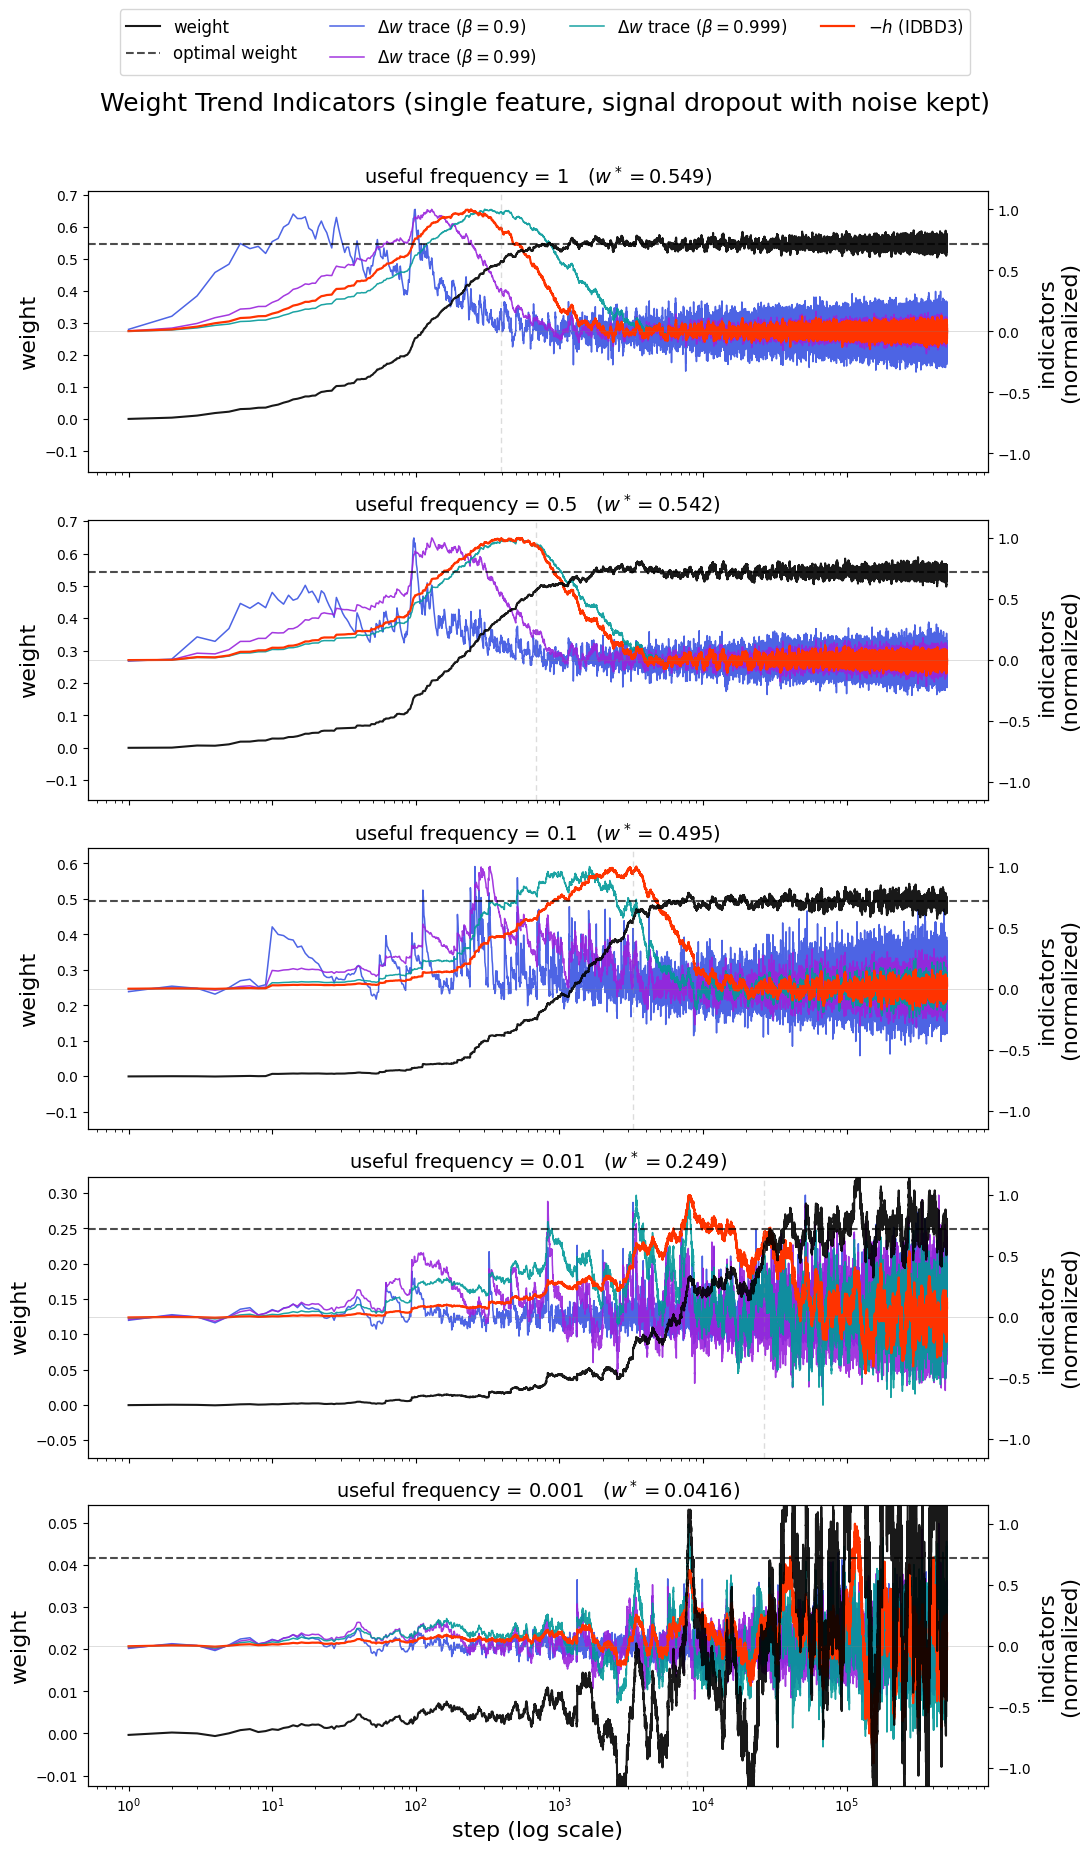

In [35]:
plot_steps = np.arange(1, N_STEPS_SD + 1)
fig, axes = plt.subplots(len(USEFUL_FREQS_SD), 1,
                         figsize=(11, 3.6 * len(USEFUL_FREQS_SD)), sharex=True)
ax2_first = None
for ax, p in zip(axes, USEFUL_FREQS_SD):
    res = results_sd[p]
    w_opt = optimal_weight_dropout(W_TEACHER_SD, FEATURE_NOISE_SD, p)  # shrinks as p falls

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9,
                 label=f'$\Delta w$ trace ($\\beta = {d}$)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='$-h$ (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(normalized)', fontsize=16)
    if ax2_first is None:
        ax2_first = ax2

    # --- left axis: the weight (true scale, black), plotted after the right axis lines ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=1.5, label='weight',
            zorder=10, alpha=0.9)
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7,
               label='optimal weight', zorder=10)
    ax.set_xscale('log')
    ax.set_ylabel('weight', fontsize=16)
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'useful frequency = {p:.3g}   ($w^* = {w_opt:.3g}$)', fontsize=14)
    ax.set_zorder(ax2.get_zorder() + 1)   # put the weight's axes above the indicator axes
    ax.patch.set_visible(False)            # but keep ax transparent so ax2 shows through

    # rough "matured" reference: weight first reaches 90% of its optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3, zorder=10)

axes[-1].set_xlabel('step (log scale)', fontsize=16)
fig.suptitle('Weight Trend Indicators (single feature, signal dropout with noise kept)', fontsize=18)

# Build legend with left and right handles/labels
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.03),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


### Seventh experiment, diagnostic: IDBD vs IDBD3 vs Autostep (rare signal)

The fifth-experiment diagnostic comparison, now on the **signal-dropout** setup of
experiment 7 (a single noisy feature whose *signal* drops out while its noise is
kept). Fixed at a hard case -- useful frequency $p = 0.001$ (the signal is present
on only ~0.1% of steps) and initial step-size $\alpha_0 = 10^{-5}$ -- to see how
each rule grows its step-size when the useful signal is rare. With only one feature
there is a single weight (no established / incumbent split); its least-squares
optimum shrinks with $p$ to $w^\star \approx 0.042$ here.

Rows are weight / $h$ / step-size $\alpha = e^{\beta}$; columns are IDBD, IDBD3,
Autostep (same rules as the fifth-experiment comparison, prediction grads so the
$h$-decay term is $x^2$). The knobs are `SD_COMPARE_FREQ`, `SD_COMPARE_INIT_SS`,
`SD_COMPARE_TAU`, and the per-rule meta-step-sizes in `SD_COMPARE_ALGOS`. Three
fresh 500k-step runs, so a bit slow.

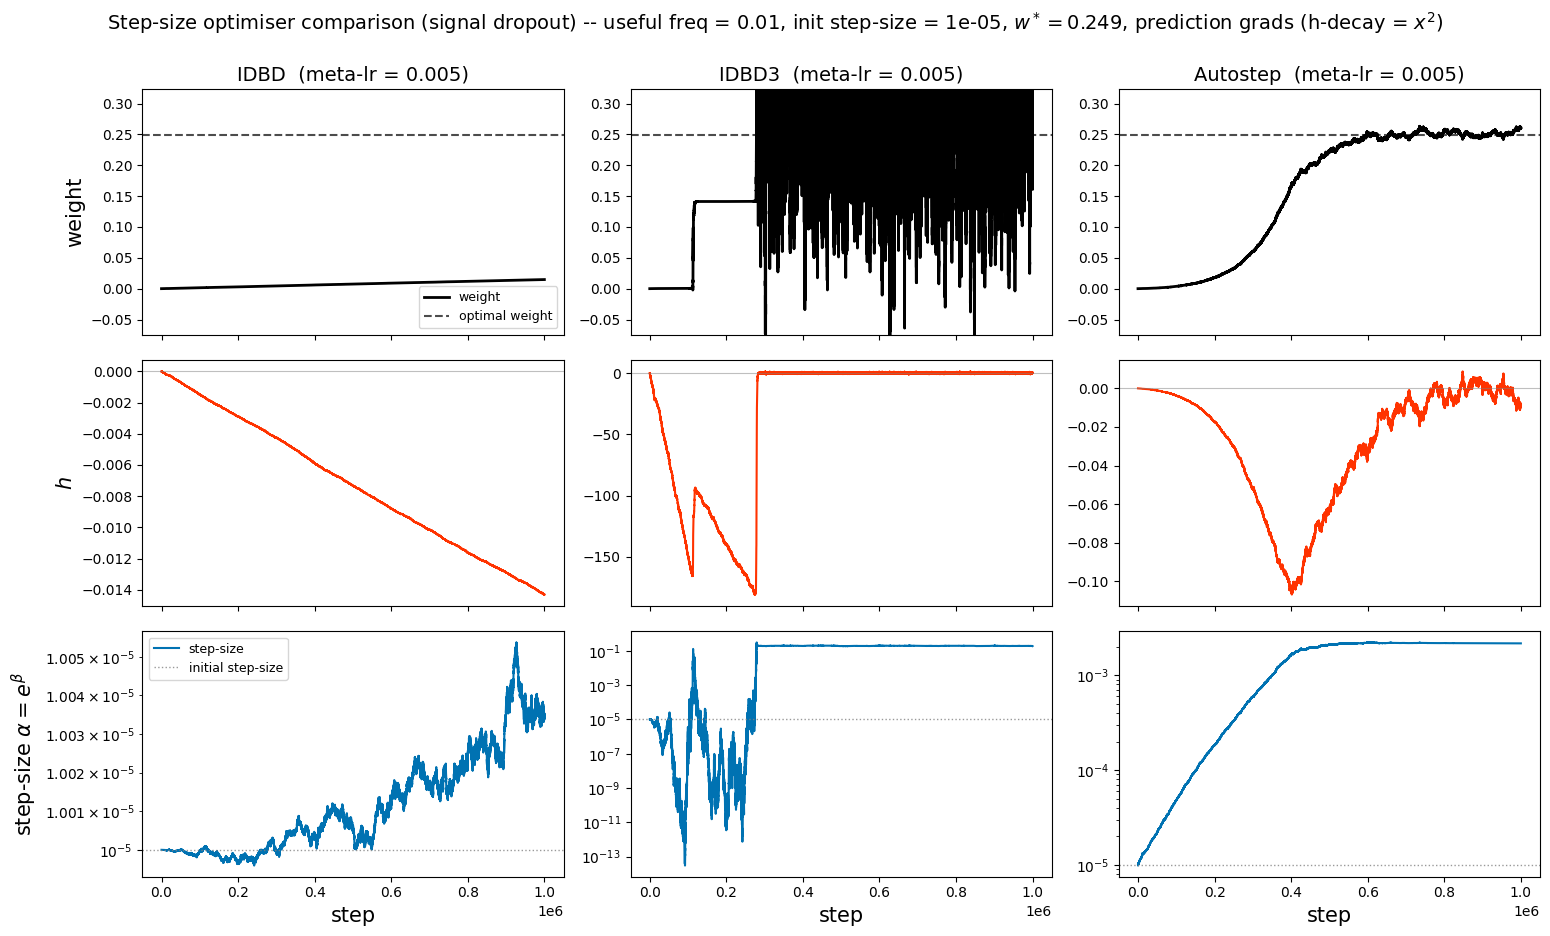

In [45]:
# ---------------------------------------------------------------------------
# Seventh experiment, diagnostic: the IDBD / IDBD3 / Autostep comparison from the
# fifth-experiment diagnostic, now on the signal-dropout setup (single noisy
# feature whose SIGNAL drops out while its noise is kept). Fixed at a hard case:
# useful frequency = 0.001 (signal present ~0.1% of steps) and initial step-size
# 1e-5, so we can see how each rule grows its step-size when the useful signal is
# rare. Single feature -> a single weight (no established/incumbent split).
# Reuses run_stepsize_opt_with_indicators and the exp-7 data helpers above.
# ---------------------------------------------------------------------------

SD_COMPARE_INIT_SS = 1e-5                   # initial step-size (all rules)
SD_COMPARE_FREQ = 0.01                      # fraction of steps the SIGNAL is present
SD_COMPARE_TAU = 1e4                        # Autostep v-tracker time constant
N_STEPS = int(1e6)
SD_COMPARE_ALGOS = [                        # (algo key, display title, meta-step-size)
    ('idbd',     'IDBD',     0.005),
    ('idbd3',    'IDBD3',    0.005),
    ('autostep', 'Autostep', 0.005),         # Autostep's meta-lr is multiplicative
]

# single noisy feature; the SIGNAL is present a fraction SD_COMPARE_FREQ of steps
feats_sd_cmp, targ_sd_cmp = make_signal_dropout_data(
    N_STEPS, W_TEACHER_SD, SD_COMPARE_FREQ,
    feature_noise=FEATURE_NOISE_SD, target_noise_std=0.1, seed=0,
)

results_sd_compare = {}
for _key, _title, _mlr in SD_COMPARE_ALGOS:
    results_sd_compare[_key] = run_stepsize_opt_with_indicators(
        feats_sd_cmp, targ_sd_cmp, algo=_key, meta_lr=_mlr,
        init_lr=SD_COMPARE_INIT_SS, tau=SD_COMPARE_TAU)   # w_init=None -> starts at zero


plot_steps = np.arange(1, N_STEPS + 1)
w_opt = optimal_weight_dropout(W_TEACHER_SD, FEATURE_NOISE_SD, SD_COMPARE_FREQ)  # shrinks as p falls
fig, axes = plt.subplots(3, len(SD_COMPARE_ALGOS),
                         figsize=(5.2 * len(SD_COMPARE_ALGOS), 9.5), sharex=True)
for col, (key, title, mlr) in enumerate(SD_COMPARE_ALGOS):
    res = results_sd_compare[key]
    ax_w, ax_h, ax_a = axes[0, col], axes[1, col], axes[2, col]

    # --- weight (true scale) ---
    ax_w.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax_w.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
    ax_w.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax_w.set_title(f'{title}  (meta-lr = {mlr:g})', fontsize=14)

    # --- h-trace, raw & signed ---
    ax_h.plot(plot_steps, res['h'][:, -1], color=H_IDBD3_COLOR, lw=1.5)
    ax_h.axhline(0.0, color='0.5', lw=0.8, alpha=0.5)

    # --- adaptive step-size alpha = exp(beta), log scale ---
    ax_a.plot(plot_steps, res['alpha'][:, -1], color=SS_COLOR, lw=1.5, label='step-size')
    ax_a.axhline(SD_COMPARE_INIT_SS, color='0.5', ls=':', lw=1.0, alpha=0.8,
                 label='initial step-size')
    ax_a.set_yscale('log')
    ax_a.set_xlabel('step', fontsize=15)

    if col == 0:
        ax_w.set_ylabel('weight', fontsize=15)
        ax_h.set_ylabel('$h$', fontsize=15)
        ax_a.set_ylabel(r'step-size $\alpha = e^{\beta}$', fontsize=15)
        ax_w.legend(fontsize=9, loc='best')
        ax_a.legend(fontsize=9, loc='best')

fig.suptitle(f'Step-size optimiser comparison (signal dropout) -- useful freq '
             f'= {SD_COMPARE_FREQ:g}, init step-size = {SD_COMPARE_INIT_SS:.3g}, '
             f'$w^* = {w_opt:.3g}$, prediction grads (h-decay = $x^2$)', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()